In [29]:
from __future__ import print_function, division
import mdtraj as md
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from mdtraj.geometry import _geometry
import os
import sys
import numpy as np
import scipy as sp
from scipy import optimize
from scipy.optimize import leastsq
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import math
import itertools    
from numpy import log2, zeros, mean, var, sum, loadtxt, arange, array, cumsum, dot, transpose, diagonal, floor
from numpy.linalg import inv, lstsq
import pyblock
from mdtraj.geometry import _geometry
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from scipy.stats import pearsonr
import json

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

In [30]:
main_path = os.getcwd()

In [31]:
hc_w76apo = json.load(open(os.path.join(main_path, 'W76A_apo','helix_contant.json'),'r'))
hc_w76apo = np.array(hc_w76apo['rep:0'])

hc_w76_sj4 = json.load(open(os.path.join(main_path, 'W76A_SJ4','helix_contant.json'),'r'))
hc_w76_sj4 = np.array(hc_w76_sj4['rep:0'])

hc_wt_apo = json.load(open(os.path.join(main_path, 'WT_apo','helix_contant.json'),'r'))
hc_wt_apo = np.array(hc_wt_apo['rep:0'])


hc_wt_sj4 = json.load(open(os.path.join(main_path, 'WT_SJ4','helix_contant.json'),'r'))
hc_wt_sj4 = np.array(hc_wt_sj4['rep:0'])

In [32]:
sc_w76apo = json.load(open(os.path.join(main_path, 'W76A_apo','sheet_contant.json'),'r'))
sc_w76apo = np.array(sc_w76apo['rep:0'])

sc_w76_sj4 = json.load(open(os.path.join(main_path, 'W76A_SJ4','sheet_contant.json'),'r'))
sc_w76_sj4 = np.array(sc_w76_sj4['rep:0'])

sc_wt_apo = json.load(open(os.path.join(main_path, 'WT_apo','sheet_contant.json'),'r'))
sc_wt_apo = np.array(sc_wt_apo['rep:0'])

sc_wt_sj4 = json.load(open(os.path.join(main_path, 'WT_SJ4','sheet_contant.json'),'r'))
sc_wt_sj4 = np.array(sc_wt_sj4['rep:0'])

In [33]:
single_letter_sequence = ['R58',
 'K59',
 'W60',
 'N61',
 'F62',
 'D63',
 'F64',
 'Q65',
 'N66',
 'H67',
 'K68',
 'P69',
 'L70',
 'E71',
 'G72',
 'K73',
 'Y74',
 'E75',
 'A76',
 'Q77',
 'E78',
 'V79',
 'E80',
 'K81',
 'G82',
 'S83',
 'L84',
 'P85',
 'E86',
 'F87',
 'Y88',
 'Y89',
 'R90',
 'P91',
 'P92',
 'R93',
 'P94',
 'P95',
 'K96',
 'G97',
 'A98',
 'C99',
 'K100',
 'V101',
 'P102',
 'A103',
 'Q104',
 'E105']

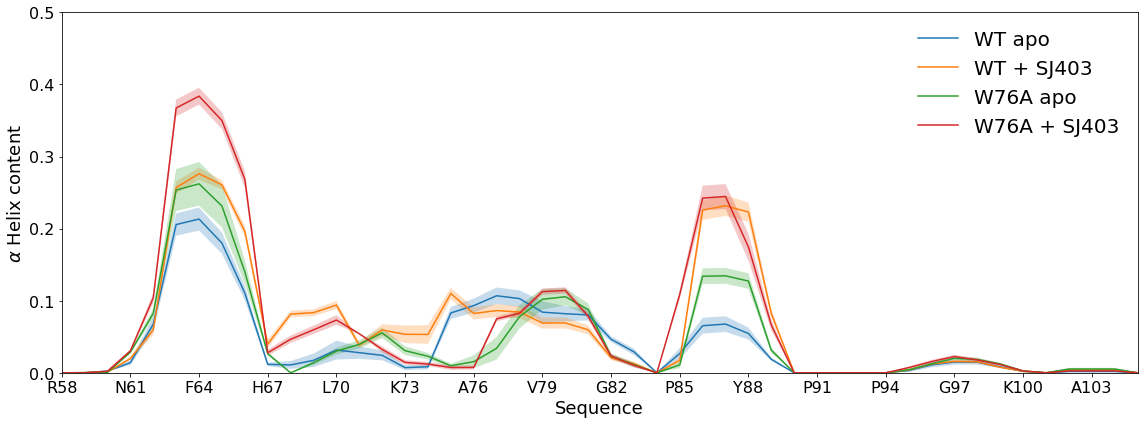

In [34]:

import numpy as np
import matplotlib.pyplot as plt

# adjustable parameters
n_xticks = 16
tick_fontsize = 16
label_fontsize = 18
legend_fontsize = 20
title_fontsize = 20

# x positions
x = np.arange(1, len(single_letter_sequence) + 1)

# means and errors
wt_apo_mean,  wt_apo_err  = hc_wt_apo[:,0],  hc_wt_apo[:,1]
wt_sj4_mean,  wt_sj4_err  = hc_wt_sj4[:,0],  hc_wt_sj4[:,1]
w76_apo_mean, w76_apo_err = hc_w76apo[:,0], hc_w76apo[:,1]
w76_sj4_mean, w76_sj4_err = hc_w76_sj4[:,0], hc_w76_sj4[:,1]

fig, ax = plt.subplots(figsize=(16,6))

# WT apo
ax.plot(x, wt_apo_mean, lw=1.5, label='WT apo')
ax.fill_between(x, wt_apo_mean-wt_apo_err, wt_apo_mean+wt_apo_err, alpha=0.25)

# WT + SJ403
ax.plot(x, wt_sj4_mean, lw=1.5, label='WT + SJ403')
ax.fill_between(x, wt_sj4_mean-wt_sj4_err, wt_sj4_mean+wt_sj4_err, alpha=0.25)

# W76A apo
ax.plot(x, w76_apo_mean, lw=1.5, label='W76A apo')
ax.fill_between(x, w76_apo_mean-w76_apo_err, w76_apo_mean+w76_apo_err, alpha=0.25)

# W76A + SJ403
ax.plot(x, w76_sj4_mean, lw=1.5, label='W76A + SJ403')
ax.fill_between(x, w76_sj4_mean-w76_sj4_err, w76_sj4_mean+w76_sj4_err, alpha=0.25)

ax.set_xlim(1, len(single_letter_sequence))
ax.set_ylim(0,1)

ax.set_xlabel("Sequence", fontsize=label_fontsize)
ax.set_ylabel(r"$\alpha$ Helix content", fontsize=label_fontsize)
# ax.set_title("Per-residue helix content", fontsize=title_fontsize)

# select evenly spaced ticks
step = len(x) // n_xticks
tick_positions = x[::step]
tick_labels = np.array(single_letter_sequence)[::step]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=tick_fontsize)

ax.tick_params(axis='y', labelsize=tick_fontsize)

ax.legend(frameon=False, fontsize=legend_fontsize)

plt.ylim(0, 0.5)

plt.tight_layout()
plt.show()

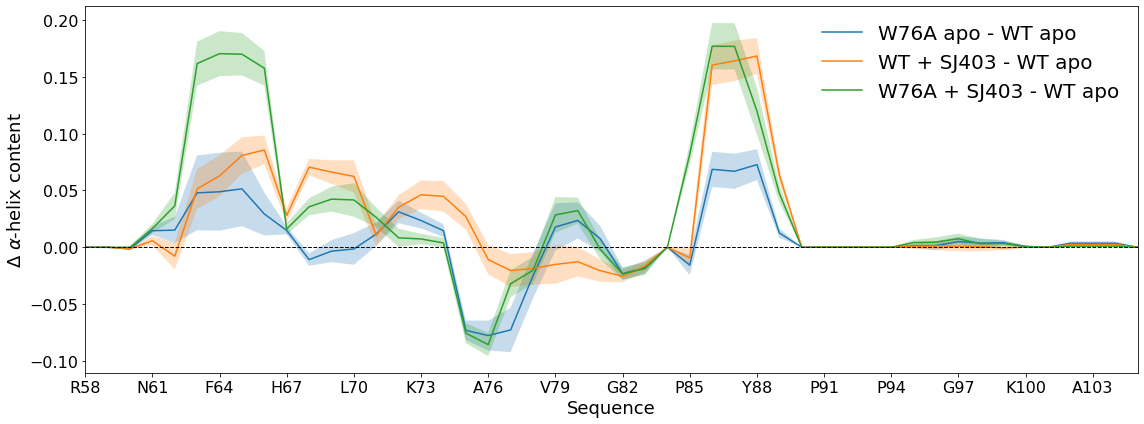

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# adjustable parameters
n_xticks = 16
tick_fontsize = 16
label_fontsize = 18
legend_fontsize = 20

# x positions
x = np.arange(1, len(single_letter_sequence) + 1)

# means and errors
wt_apo_mean,  wt_apo_err  = hc_wt_apo[:,0],   hc_wt_apo[:,1]
wt_sj4_mean,  wt_sj4_err  = hc_wt_sj4[:,0],   hc_wt_sj4[:,1]
w76_apo_mean, w76_apo_err = hc_w76apo[:,0],   hc_w76apo[:,1]
w76_sj4_mean, w76_sj4_err = hc_w76_sj4[:,0],  hc_w76_sj4[:,1]

# differences
diff_w76apo_vs_wtapo = w76_apo_mean - wt_apo_mean
diff_wtsj4_vs_wtapo  = wt_sj4_mean - wt_apo_mean
diff_w76sj4_vs_wtapo = w76_sj4_mean - wt_apo_mean

# propagated errors: sigma_diff = sqrt(sigma1^2 + sigma2^2)
err_w76apo_vs_wtapo = np.sqrt(w76_apo_err**2 + wt_apo_err**2)
err_wtsj4_vs_wtapo  = np.sqrt(wt_sj4_err**2 + wt_apo_err**2)
err_w76sj4_vs_wtapo = np.sqrt(w76_sj4_err**2 + wt_apo_err**2)

fig, ax = plt.subplots(figsize=(16,6))

# W76A apo - WT apo
ax.plot(x, diff_w76apo_vs_wtapo, lw=1.5, label='W76A apo - WT apo')
ax.fill_between(
    x,
    diff_w76apo_vs_wtapo - err_w76apo_vs_wtapo,
    diff_w76apo_vs_wtapo + err_w76apo_vs_wtapo,
    alpha=0.25
)

# WT + SJ4 - WT apo
ax.plot(x, diff_wtsj4_vs_wtapo, lw=1.5, label='WT + SJ403 - WT apo')
ax.fill_between(
    x,
    diff_wtsj4_vs_wtapo - err_wtsj4_vs_wtapo,
    diff_wtsj4_vs_wtapo + err_wtsj4_vs_wtapo,
    alpha=0.25
)

# W76A + SJ4 - WT apo
ax.plot(x, diff_w76sj4_vs_wtapo, lw=1.5, label='W76A + SJ403 - WT apo')
ax.fill_between(
    x,
    diff_w76sj4_vs_wtapo - err_w76sj4_vs_wtapo,
    diff_w76sj4_vs_wtapo + err_w76sj4_vs_wtapo,
    alpha=0.25
)

# zero line
ax.axhline(0, color='black', lw=1, ls='--')

ax.set_xlim(1, len(single_letter_sequence))
ax.set_xlabel("Sequence", fontsize=label_fontsize)
ax.set_ylabel(r"$\Delta$ $\alpha$-helix content", fontsize=label_fontsize)

# evenly spaced ticks
step = max(1, len(x) // n_xticks)
tick_positions = x[::step]
tick_labels = np.array(single_letter_sequence)[::step]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=tick_fontsize)
ax.tick_params(axis='y', labelsize=tick_fontsize)

ax.legend(frameon=False, fontsize=legend_fontsize)

plt.tight_layout()
plt.show()

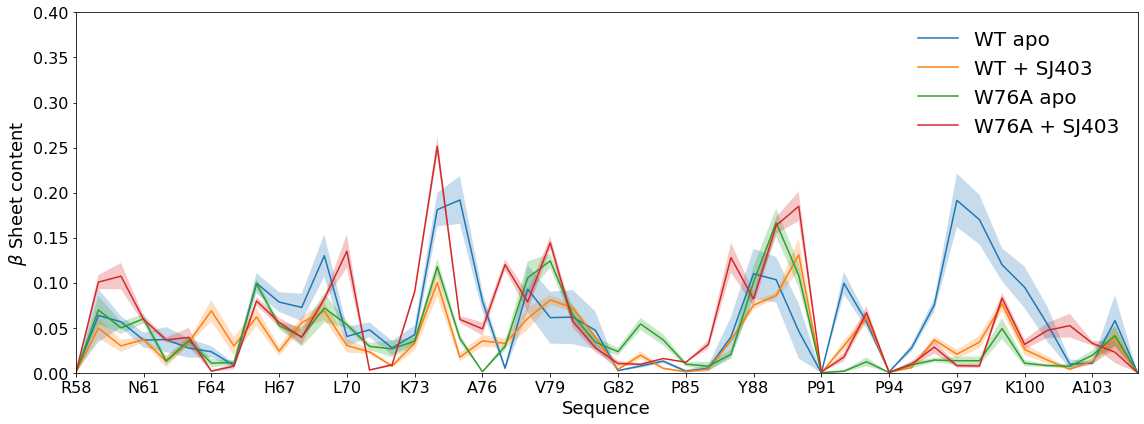

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# adjustable parameters
n_xticks = 16
tick_fontsize = 16
label_fontsize = 18
legend_fontsize = 20
title_fontsize = 20

# x positions
x = np.arange(1, len(single_letter_sequence) + 1)

# means and errors
wt_apo_mean,  wt_apo_err  = sc_wt_apo[:,0],  sc_wt_apo[:,1]
wt_sj4_mean,  wt_sj4_err  = sc_wt_sj4[:,0],  sc_wt_sj4[:,1]
w76_apo_mean, w76_apo_err = sc_w76apo[:,0], sc_w76apo[:,1]
w76_sj4_mean, w76_sj4_err = sc_w76_sj4[:,0], sc_w76_sj4[:,1]

fig, ax = plt.subplots(figsize=(16,6))

# WT apo
ax.plot(x, wt_apo_mean, lw=1.5, label='WT apo')
ax.fill_between(x, wt_apo_mean-wt_apo_err, wt_apo_mean+wt_apo_err, alpha=0.25)

# WT + SJ403
ax.plot(x, wt_sj4_mean, lw=1.5, label='WT + SJ403')
ax.fill_between(x, wt_sj4_mean-wt_sj4_err, wt_sj4_mean+wt_sj4_err, alpha=0.25)

# W76A apo
ax.plot(x, w76_apo_mean, lw=1.5, label='W76A apo')
ax.fill_between(x, w76_apo_mean-w76_apo_err, w76_apo_mean+w76_apo_err, alpha=0.25)

# W76A + SJ403
ax.plot(x, w76_sj4_mean, lw=1.5, label='W76A + SJ403')
ax.fill_between(x, w76_sj4_mean-w76_sj4_err, w76_sj4_mean+w76_sj4_err, alpha=0.25)

ax.set_xlim(1, len(single_letter_sequence))
ax.set_ylim(0,1)

ax.set_xlabel("Sequence", fontsize=label_fontsize)
ax.set_ylabel(r"$\beta$ Sheet content", fontsize=label_fontsize)
# ax.set_title("Per-residue helix content", fontsize=title_fontsize)

# select evenly spaced ticks
step = len(x) // n_xticks
tick_positions = x[::step]
tick_labels = np.array(single_letter_sequence)[::step]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=tick_fontsize)

ax.tick_params(axis='y', labelsize=tick_fontsize)

ax.legend(frameon=False, fontsize=legend_fontsize)

plt.ylim(0, 0.4)

plt.tight_layout()
plt.show()


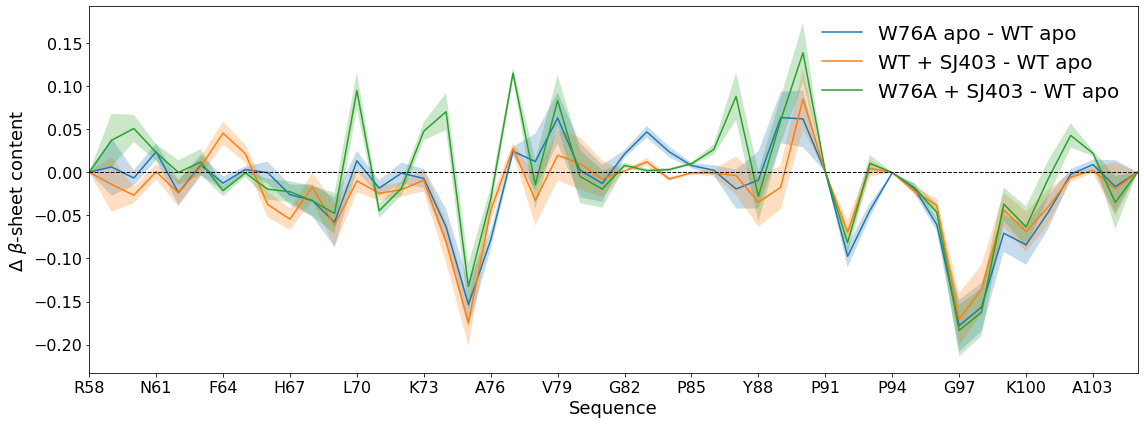

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# adjustable parameters
n_xticks = 16
tick_fontsize = 16
label_fontsize = 18
legend_fontsize = 20

# x positions
x = np.arange(1, len(single_letter_sequence) + 1)

# means and errors
wt_apo_mean,  wt_apo_err  = sc_wt_apo[:,0],   sc_wt_apo[:,1]
wt_sj4_mean,  wt_sj4_err  = sc_wt_sj4[:,0],   sc_wt_sj4[:,1]
w76_apo_mean, w76_apo_err = sc_w76apo[:,0],   sc_w76apo[:,1]
w76_sj4_mean, w76_sj4_err = sc_w76_sj4[:,0],  sc_w76_sj4[:,1]

# differences
diff_w76apo_vs_wtapo = w76_apo_mean - wt_apo_mean
diff_wtsj4_vs_wtapo  = wt_sj4_mean - wt_apo_mean
diff_w76sj4_vs_wtapo = w76_sj4_mean - wt_apo_mean

# propagated errors: sigma_diff = sqrt(sigma1^2 + sigma2^2)
err_w76apo_vs_wtapo = np.sqrt(w76_apo_err**2 + wt_apo_err**2)
err_wtsj4_vs_wtapo  = np.sqrt(wt_sj4_err**2 + wt_apo_err**2)
err_w76sj4_vs_wtapo = np.sqrt(w76_sj4_err**2 + wt_apo_err**2)

fig, ax = plt.subplots(figsize=(16,6))

# W76A apo - WT apo
ax.plot(x, diff_w76apo_vs_wtapo, lw=1.5, label='W76A apo - WT apo')
ax.fill_between(
    x,
    diff_w76apo_vs_wtapo - err_w76apo_vs_wtapo,
    diff_w76apo_vs_wtapo + err_w76apo_vs_wtapo,
    alpha=0.25
)

# WT + SJ4 - WT apo
ax.plot(x, diff_wtsj4_vs_wtapo, lw=1.5, label='WT + SJ403 - WT apo')
ax.fill_between(
    x,
    diff_wtsj4_vs_wtapo - err_wtsj4_vs_wtapo,
    diff_wtsj4_vs_wtapo + err_wtsj4_vs_wtapo,
    alpha=0.25
)

# W76A + SJ4 - WT apo
ax.plot(x, diff_w76sj4_vs_wtapo, lw=1.5, label='W76A + SJ403 - WT apo')
ax.fill_between(
    x,
    diff_w76sj4_vs_wtapo - err_w76sj4_vs_wtapo,
    diff_w76sj4_vs_wtapo + err_w76sj4_vs_wtapo,
    alpha=0.25
)

# zero line
ax.axhline(0, color='black', lw=1, ls='--')

ax.set_xlim(1, len(single_letter_sequence))
ax.set_xlabel("Sequence", fontsize=label_fontsize)
ax.set_ylabel(r"$\Delta$ $\beta$-sheet content", fontsize=label_fontsize)

# evenly spaced ticks
step = max(1, len(x) // n_xticks)
tick_positions = x[::step]
tick_labels = np.array(single_letter_sequence)[::step]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=tick_fontsize)
ax.tick_params(axis='y', labelsize=tick_fontsize)

ax.legend(frameon=False, fontsize=legend_fontsize)

plt.tight_layout()
plt.show()

In [38]:
pdb1 = os.path.join(main_path, 'WT_SJ4', 'prot_lig.pdb')
trajectory1 = os.path.join(main_path, 'WT_SJ4', 'rep.0.xtc')
pdb1 = md.load_pdb(pdb1)

traj1 = md.load_xtc(trajectory1, top=pdb1.topology)
traj1.center_coordinates()


pdb2 = os.path.join(main_path, 'W76A_SJ4', 'prot_lig.pdb')
trajectory2 = os.path.join(main_path, 'W76A_SJ4', 'rep.0.xtc')
pdb2 = md.load_pdb(pdb2)

traj2 = md.load_xtc(trajectory2, top=pdb2.topology)
traj2.center_coordinates()

<mdtraj.Trajectory with 49027 frames, 854 atoms, 73 residues, and unitcells at 0x7fef88a61a50>

 resSeq resname_WT resname_W76A  helix_frac_WT  helix_frac_W76A  delta_W76A_minus_WT
     58        ARG          ARG          0.000            0.000                0.000
     59        LYS          LYS          0.000            0.000               -0.000
     60        TRP          TRP          0.001            0.002                0.001
     61        ASN          ASN          0.020            0.030                0.011
     62        PHE          PHE          0.059            0.104                0.044
     63        ASP          ASP          0.257            0.367                0.110
     64        PHE          PHE          0.276            0.384                0.108
     65        GLN          GLN          0.261            0.350                0.089
     66        ASN          ASN          0.196            0.268                0.072
     67        HIS          HIS          0.040            0.028               -0.012
     68        LYS          LYS          0.081            0.047  

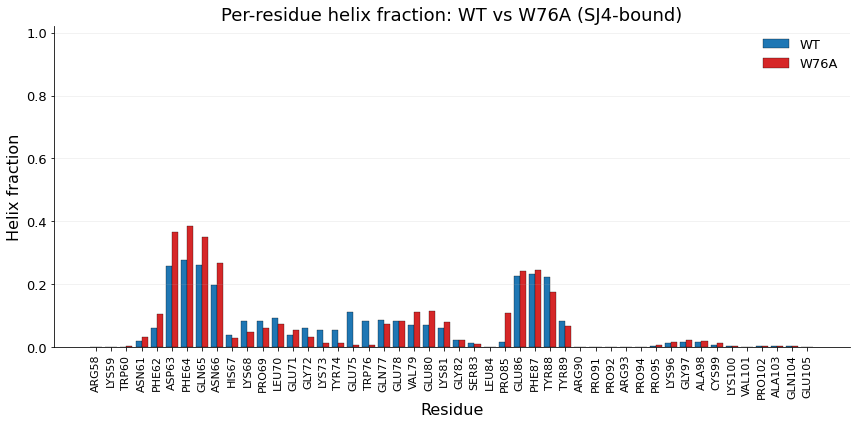

Saved plot  -> helix_fraction_per_residue.png / .pdf


(<Figure size 864x432 with 1 Axes>,
 <AxesSubplot:title={'center':'Per-residue helix fraction: WT vs W76A (SJ4-bound)'}, xlabel='Residue', ylabel='Helix fraction'>)

In [39]:
"""
Compare per-residue helix fractions between WT (traj1) and W76A (traj2)
simulations of a protein-ligand system using DSSP.

Assumes `traj1` and `traj2` are already in memory (mdtraj Trajectory objects).
If not, uncomment the loader block below.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mdtraj as md

# -----------------------------------------------------------------------------
# (Optional) reload trajectories — skip if traj1/traj2 already live in memory
# -----------------------------------------------------------------------------
# main_path = "..."
# pdb1  = md.load_pdb(os.path.join(main_path, 'WT_SJ4',   'prot_lig.pdb'))
# traj1 = md.load_xtc(os.path.join(main_path, 'WT_SJ4',   'rep.0.xtc'), top=pdb1.topology)
# traj1.center_coordinates()
# pdb2  = md.load_pdb(os.path.join(main_path, 'W76A_SJ4', 'prot_lig.pdb'))
# traj2 = md.load_xtc(os.path.join(main_path, 'W76A_SJ4', 'rep.0.xtc'), top=pdb2.topology)
# traj2.center_coordinates()

# -----------------------------------------------------------------------------
# 1. Restrict to protein only — DSSP is undefined on the ligand
# -----------------------------------------------------------------------------
def protein_slice(traj):
    """Return a trajectory containing only protein atoms."""
    prot_atoms = traj.topology.select("protein")
    return traj.atom_slice(prot_atoms)

traj1_prot = protein_slice(traj1)
traj2_prot = protein_slice(traj2)

# -----------------------------------------------------------------------------
# 2. Compute DSSP for every frame
#    simplified=True gives {'H' helix, 'E' strand, 'C' coil/other}
#    shape: (n_frames, n_residues)
# -----------------------------------------------------------------------------
dssp1 = md.compute_dssp(traj1_prot, simplified=True)
dssp2 = md.compute_dssp(traj2_prot, simplified=True)

# Helix fraction per residue = fraction of frames with 'H'
helix_frac1 = (dssp1 == "H").mean(axis=0)
helix_frac2 = (dssp2 == "H").mean(axis=0)

# -----------------------------------------------------------------------------
# 3. Build residue labels. We assume both topologies have the same residues in
#    the same order (typical for a point mutant). If one is longer we align on
#    the shorter one and warn.
# -----------------------------------------------------------------------------
res1 = [r for r in traj1_prot.topology.residues]
res2 = [r for r in traj2_prot.topology.residues]

n = min(len(res1), len(res2))
if len(res1) != len(res2):
    print(f"[warn] residue count differs: WT={len(res1)}, W76A={len(res2)}. "
          f"Comparing the first {n} residues.")

resSeq   = [res1[i].resSeq for i in range(n)]           # PDB residue number
resname1 = [res1[i].name   for i in range(n)]
resname2 = [res2[i].name   for i in range(n)]
labels   = [f"{resname1[i]}{resSeq[i]}" for i in range(n)]

helix_frac1 = helix_frac1[:n]
helix_frac2 = helix_frac2[:n]

# -----------------------------------------------------------------------------
# 4. Table of helix fractions
# -----------------------------------------------------------------------------
df = pd.DataFrame({
    "resSeq":         resSeq,
    "resname_WT":     resname1,
    "resname_W76A":   resname2,
    "helix_frac_WT":   helix_frac1,
    "helix_frac_W76A": helix_frac2,
    "delta_W76A_minus_WT": helix_frac2 - helix_frac1,
})

# Round for readability but keep full precision in the CSV
df_display = df.copy()
for c in ["helix_frac_WT", "helix_frac_W76A", "delta_W76A_minus_WT"]:
    df_display[c] = df_display[c].round(3)

print(df_display.to_string(index=False))

df.to_csv("helix_fractions_per_residue.csv", index=False)
print("\nSaved table -> helix_fractions_per_residue.csv")

# -----------------------------------------------------------------------------
# 5. Grouped bar plot (WT vs W76A, per residue)
# -----------------------------------------------------------------------------
def plot_helix_fractions(
    helix_frac1,
    helix_frac2,
    labels,
    *,
    # --- font-size knobs (all in points) ---
    title_fs=16,
    axis_label_fs=14,
    xtick_fs=10,
    ytick_fs=12,
    legend_fs=12,
    # --- other styling knobs ---
    figsize=None,           # e.g. (18, 5); auto-scales with n if None
    bar_width=0.4,
    xtick_rotation=90,
    max_xticks=60,          # thin labels if more residues than this
    dpi=200,
    out_prefix="helix_fraction_per_residue",
    title="Per-residue helix fraction: WT vs W76A (SJ4-bound)",
    wt_label="WT",
    mut_label="W76A",
    wt_color="#1f77b4",
    mut_color="#d62728",
    show=True,
):
    """Grouped bar plot of WT vs mutant helix fractions.

    All font sizes are keyword arguments so you can tune any of them:
        plot_helix_fractions(helix_frac1, helix_frac2, labels,
                             title_fs=20, axis_label_fs=18, xtick_fs=12)
    """
    n = len(labels)
    x = np.arange(n)
    w = bar_width

    if figsize is None:
        figsize = (max(10, n * 0.18), 5)

    fig, ax = plt.subplots(figsize=(12,6))

    ax.bar(x - w/2, helix_frac1, width=w, label=wt_label,
           color=wt_color,  edgecolor="black", linewidth=0.3)
    ax.bar(x + w/2, helix_frac2, width=w, label=mut_label,
           color=mut_color, edgecolor="black", linewidth=0.3)

    ax.set_xlabel("Residue",        fontsize=axis_label_fs)
    ax.set_ylabel("Helix fraction", fontsize=axis_label_fs)
    ax.set_title(title,             fontsize=title_fs)
    ax.set_ylim(0, 1.02)
    ax.set_xticks(x)

    # Thin out tick labels if too many residues to fit
    if n > max_xticks:
        step = max(1, n // max_xticks)
        keep = set(range(0, n, step))
        shown = [lbl if i in keep else "" for i, lbl in enumerate(labels)]
    else:
        shown = list(labels)

    ax.set_xticklabels(shown, rotation=xtick_rotation, fontsize=xtick_fs)
    ax.tick_params(axis="y", labelsize=ytick_fs)

    ax.legend(frameon=False, fontsize=legend_fs)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=dpi)
    fig.savefig(f"{out_prefix}.pdf")
    if show:
        plt.show()
    print(f"Saved plot  -> {out_prefix}.png / .pdf")
    return fig, ax


# --- call it (tweak any of the *_fs values to taste) ---
plot_helix_fractions(
    helix_frac1, helix_frac2, labels,
    title_fs=18,
    axis_label_fs=16,
    xtick_fs=11,
    ytick_fs=13,
    legend_fs=13,
)

Saved table -> bound_fractions_per_residue.csv


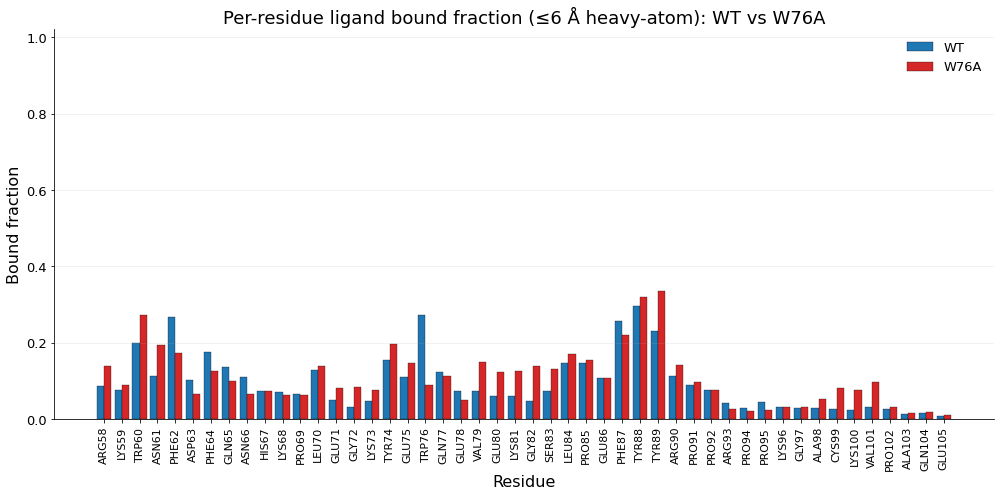

Saved plot  -> bound_fraction_per_residue_all.png / .pdf


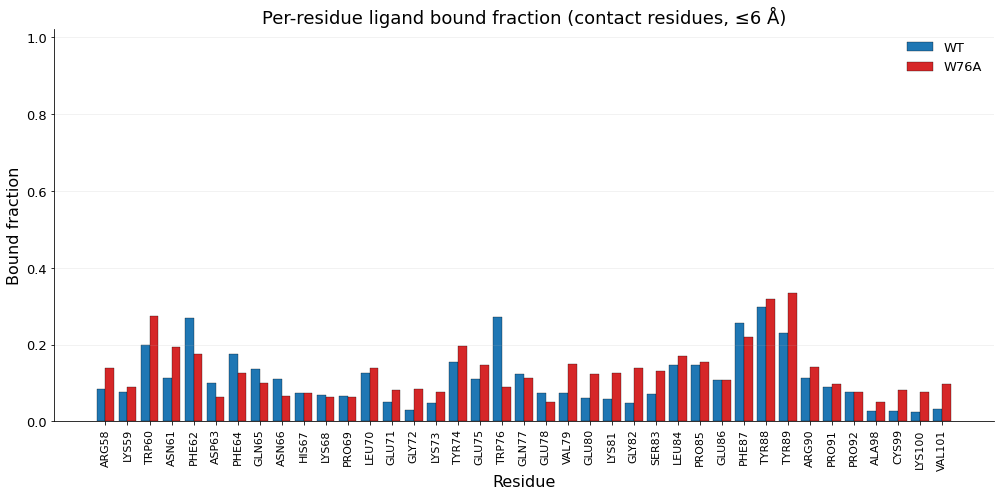

Saved plot  -> bound_fraction_per_residue_contacts.png / .pdf


(<Figure size 1008x504 with 1 Axes>,
 <AxesSubplot:title={'center':'Per-residue ligand bound fraction (contact residues, ≤6 Å)'}, xlabel='Residue', ylabel='Bound fraction'>)

In [40]:

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
LIGAND_RESNAME = "SJ4"
CUTOFF_NM      = 0.6          # 6.0 Å in nanometers (mdtraj uses nm)

# -----------------------------------------------------------------------------
# 1. Compute per-residue bound fraction for one trajectory
# -----------------------------------------------------------------------------
def compute_bound_fraction(traj, ligand_resname=LIGAND_RESNAME, cutoff_nm=CUTOFF_NM):
    """Return (bound_frac, labels, resSeqs) for every protein residue in traj.

    bound_frac[i] = fraction of frames where residue i has at least one heavy
    atom within `cutoff_nm` of any heavy atom of the ligand.
    """
    top = traj.topology

    # Ligand residue index (expects exactly one residue with that name)
    lig_residues = [r for r in top.residues if r.name == ligand_resname]
    if len(lig_residues) == 0:
        raise ValueError(f"No residue named '{ligand_resname}' found in topology.")
    if len(lig_residues) > 1:
        print(f"[warn] found {len(lig_residues)} '{ligand_resname}' residues; "
              f"using the first (index {lig_residues[0].index}).")
    lig_idx = lig_residues[0].index

    # Protein residue indices
    prot_residues = [r for r in top.residues if r.is_protein]
    prot_idx = [r.index for r in prot_residues]

    # md.compute_contacts with scheme='closest-heavy' gives the minimum
    # heavy-atom-to-heavy-atom distance between each pair of residues,
    # in nm. Shape: (n_frames, n_pairs)
    pairs = np.array([[i, lig_idx] for i in prot_idx])
    distances, _ = md.compute_contacts(traj, contacts=pairs,
                                       scheme="closest-heavy",
                                       periodic=True)

    bound_frac = (distances <= cutoff_nm).mean(axis=0)

    labels  = [f"{r.name}{r.resSeq}" for r in prot_residues]
    resSeqs = [r.resSeq for r in prot_residues]
    resnames = [r.name  for r in prot_residues]
    return bound_frac, labels, resSeqs, resnames


bf1, labels1, resSeqs1, resnames1 = compute_bound_fraction(traj1)
bf2, labels2, resSeqs2, resnames2 = compute_bound_fraction(traj2)

# Align on shorter topology if they happen to differ (shouldn't, for a point mutant)
n = min(len(bf1), len(bf2))
if len(bf1) != len(bf2):
    print(f"[warn] protein residue count differs: WT={len(bf1)}, W76A={len(bf2)}. "
          f"Comparing the first {n}.")
bf1      = bf1[:n]
bf2      = bf2[:n]
resSeqs  = resSeqs1[:n]
resnames_wt  = resnames1[:n]
resnames_mut = resnames2[:n]
labels   = [f"{resnames_wt[i]}{resSeqs[i]}" for i in range(n)]

# -----------------------------------------------------------------------------
# 2. Save table  (same style as the helix-fraction table)
# -----------------------------------------------------------------------------
df_bound = pd.DataFrame({
    "resSeq":              resSeqs,
    "resname_WT":          resnames_wt,
    "resname_W76A":        resnames_mut,
    "bound_frac_WT":       bf1,
    "bound_frac_W76A":     bf2,
    "delta_W76A_minus_WT": bf2 - bf1,
})
df_bound.to_csv("bound_fractions_per_residue.csv", index=False)
print("Saved table -> bound_fractions_per_residue.csv")

# -----------------------------------------------------------------------------
# 3. Grouped bar plot — same font-size knobs as before
# -----------------------------------------------------------------------------
def plot_bound_fractions(
    bf1, bf2, labels,
    *,
    # font sizes (pt)
    title_fs=18,
    axis_label_fs=16,
    xtick_fs=11,
    ytick_fs=13,
    legend_fs=13,
    # styling
    figsize=None,
    bar_width=0.4,
    xtick_rotation=90,
    max_xticks=60,          # if >this many residues, thin tick labels
    only_contacts=False,    # if True, plot only residues with bf>0 in either traj
    contact_threshold=0.0,  # bound frac >= this in either traj to be shown when only_contacts
    dpi=200,
    out_prefix="bound_fraction_per_residue",
    title="Per-residue ligand bound fraction (\u22646 \u00c5 heavy-atom): WT vs W76A",
    wt_label="WT",
    mut_label="W76A",
    wt_color="#1f77b4",
    mut_color="#d62728",
    show=True,
):
    """Grouped bar plot of WT vs mutant per-residue bound fraction.

    Binding is typically sparse (most residues never touch the ligand), so the
    full-protein plot can look empty. Set `only_contacts=True` to restrict
    the plot to residues that actually contact the ligand in at least one
    trajectory (bound fraction > `contact_threshold`).
    """
    bf1 = np.asarray(bf1)
    bf2 = np.asarray(bf2)
    labels = list(labels)

    if only_contacts:
        mask = (bf1 > contact_threshold) | (bf2 > contact_threshold)
        bf1    = bf1[mask]
        bf2    = bf2[mask]
        labels = [l for l, m in zip(labels, mask) if m]

    n = len(labels)
    x = np.arange(n)
    w = bar_width

    if figsize is None:
        figsize = (max(10, n * 0.22), 5)

    fig, ax = plt.subplots(figsize=(14,7))
    ax.bar(x - w/2, bf1, width=w, label=wt_label,
           color=wt_color,  edgecolor="black", linewidth=0.3)
    ax.bar(x + w/2, bf2, width=w, label=mut_label,
           color=mut_color, edgecolor="black", linewidth=0.3)

    ax.set_xlabel("Residue",           fontsize=axis_label_fs)
    ax.set_ylabel("Bound fraction",    fontsize=axis_label_fs)
    ax.set_title(title,                fontsize=title_fs)
    ax.set_ylim(0, 1.02)
    ax.set_xticks(x)

    if n > max_xticks:
        step = max(1, n // max_xticks)
        keep = set(range(0, n, step))
        shown = [lbl if i in keep else "" for i, lbl in enumerate(labels)]
    else:
        shown = labels
    ax.set_xticklabels(shown, rotation=xtick_rotation, fontsize=xtick_fs)
    ax.tick_params(axis="y", labelsize=ytick_fs)

    ax.legend(frameon=False, fontsize=legend_fs)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=dpi)
    fig.savefig(f"{out_prefix}.pdf")
    if show:
        plt.show()
    print(f"Saved plot  -> {out_prefix}.png / .pdf")
    return fig, ax


# --- full-protein view ---
plot_bound_fractions(
    bf1, bf2, labels,
    out_prefix="bound_fraction_per_residue_all",
)

# --- contacts-only view (much easier to read) ---
plot_bound_fractions(
    bf1, bf2, labels,
    only_contacts=True,
    contact_threshold=0.05,   # keep residues bound in >=5% of frames in either traj
    out_prefix="bound_fraction_per_residue_contacts",
    title="Per-residue ligand bound fraction (contact residues, \u22646 \u00c5)",
)

   region  bound_frac_WT  bound_frac_W76A  delta_W76A_minus_WT
    Total          0.683            0.684                0.001
 H1+H2+H3          0.624            0.610               -0.014
    H1+H2          0.529            0.459               -0.070
    H2+H3          0.528            0.524               -0.004
    H1+H3          0.527            0.559                0.032
       H1          0.366            0.301               -0.065
       H2          0.321            0.315               -0.006
       H3          0.374            0.410                0.036

Saved table -> helix_region_bound_fractions.csv


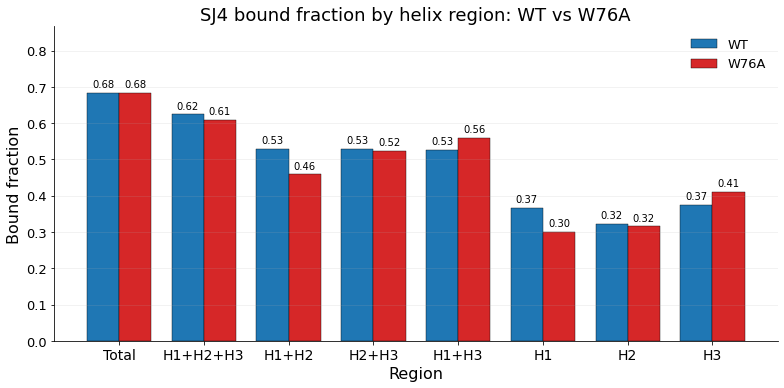

Saved plot  -> helix_region_bound_fractions.png / .pdf


(<Figure size 792x396 with 1 Axes>,
 <AxesSubplot:title={'center':'SJ4 bound fraction by helix region: WT vs W76A'}, xlabel='Region', ylabel='Bound fraction'>)

In [41]:
"""
Helix-region bound fractions: WT (traj1) vs W76A (traj2).

For each trajectory, compute the fraction of frames in which SJ4 is within
0.6 nm (heavy-atom-to-heavy-atom) of any residue in a given set of helices:

    1. Total         - any protein residue
    2. H1 + H2 + H3  - any residue in H1, H2 or H3
    3. H1 + H2       - any residue in H1 or H2
    4. H2 + H3       - any residue in H2 or H3
    5. H1 + H3       - any residue in H1 or H3
    6. H1            - any residue in H1
    7. H2            - any residue in H2
    8. H3            - any residue in H3

Helix definitions (inclusive resSeq ranges):
    H1: PHE62 - ASN66   (resSeq 62-66)
    H2: GLU75 - GLU80   (resSeq 75-80)
    H3: GLU86 - TYR88   (resSeq 86-88)

Assumes `traj1` (WT) and `traj2` (W76A) are already loaded.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mdtraj as md

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
LIGAND_RESNAME = "SJ4"
CUTOFF_NM      = 0.6          # 6.0 Å

HELICES = {
    "H1": list(range(62, 66 + 1)),   # PHE62 .. ASN66
    "H2": list(range(75, 80 + 1)),   # GLU75 .. GLU80
    "H3": list(range(86, 88 + 1)),   # GLU86 .. TYR88
}

# -----------------------------------------------------------------------------
# 1. Per-frame contact arrays
# -----------------------------------------------------------------------------
def residue_ligand_contacts(traj, ligand_resname=LIGAND_RESNAME, cutoff_nm=CUTOFF_NM):
    """Return a (n_frames, n_prot_residues) boolean array: is each residue
    within `cutoff_nm` of any ligand heavy atom in each frame? Also returns
    the list of protein residues (same order as columns)."""
    top = traj.topology
    lig = [r for r in top.residues if r.name == ligand_resname]
    if not lig:
        raise ValueError(f"No residue named '{ligand_resname}' in topology.")
    lig_idx = lig[0].index

    prot_res = [r for r in top.residues if r.is_protein]
    pairs = np.array([[r.index, lig_idx] for r in prot_res])

    # min heavy-atom-heavy-atom distance per pair per frame, in nm
    d, _ = md.compute_contacts(traj, contacts=pairs,
                               scheme="closest-heavy", periodic=True)
    return d <= cutoff_nm, prot_res


def region_bound_fractions(traj, helices=HELICES):
    """Compute the 8 region bound fractions for one trajectory."""
    contact, prot_res = residue_ligand_contacts(traj)   # (n_frames, n_res), list
    resSeqs = np.array([r.resSeq for r in prot_res])

    # Per-helix per-frame: does SJ4 touch *any* residue in this helix?
    h_contact = {}
    for hname, hresSeqs in helices.items():
        mask = np.isin(resSeqs, list(hresSeqs))
        if not mask.any():
            print(f"[warn] no residues matched for {hname} "
                  f"(resSeqs {list(hresSeqs)} not found in protein).")
            h_contact[hname] = np.zeros(contact.shape[0], dtype=bool)
        else:
            h_contact[hname] = contact[:, mask].any(axis=1)

    total = contact.any(axis=1)     # any protein residue

    return {
        "Total":    total.mean(),
        "H1+H2+H3": (h_contact["H1"] | h_contact["H2"] | h_contact["H3"]).mean(),
        "H1+H2":    (h_contact["H1"] | h_contact["H2"]).mean(),
        "H2+H3":    (h_contact["H2"] | h_contact["H3"]).mean(),
        "H1+H3":    (h_contact["H1"] | h_contact["H3"]).mean(),
        "H1":       h_contact["H1"].mean(),
        "H2":       h_contact["H2"].mean(),
        "H3":       h_contact["H3"].mean(),
    }


# -----------------------------------------------------------------------------
# 2. Compute for both trajectories
# -----------------------------------------------------------------------------
res_wt  = region_bound_fractions(traj1)
res_mut = region_bound_fractions(traj2)

categories = list(res_wt.keys())
wt_vals  = np.array([res_wt[c]  for c in categories])
mut_vals = np.array([res_mut[c] for c in categories])

df = pd.DataFrame({
    "region":              categories,
    "bound_frac_WT":       wt_vals,
    "bound_frac_W76A":     mut_vals,
    "delta_W76A_minus_WT": mut_vals - wt_vals,
})
print(df.round(3).to_string(index=False))
df.to_csv("helix_region_bound_fractions.csv", index=False)
print("\nSaved table -> helix_region_bound_fractions.csv")

# -----------------------------------------------------------------------------
# 3. Grouped bar plot — same font-size knob pattern as before
# -----------------------------------------------------------------------------
def plot_region_bound_fractions(
    categories, wt_vals, mut_vals,
    *,
    # font sizes (pt)
    title_fs=18,
    axis_label_fs=16,
    xtick_fs=14,
    ytick_fs=13,
    legend_fs=13,
    value_label_fs=10,
    # styling
    figsize=(11, 5.5),
    bar_width=0.38,
    xtick_rotation=0,
    show_values=True,          # write the numeric value on top of each bar
    dpi=200,
    out_prefix="helix_region_bound_fractions",
    title="SJ4 bound fraction by helix region: WT vs W76A",
    wt_label="WT",
    mut_label="W76A",
    wt_color="#1f77b4",
    mut_color="#d62728",
    show=True,
):
    wt_vals  = np.asarray(wt_vals)
    mut_vals = np.asarray(mut_vals)
    n = len(categories)
    x = np.arange(n)
    w = bar_width

    fig, ax = plt.subplots(figsize=figsize)
    bars_wt  = ax.bar(x - w/2, wt_vals,  width=w, label=wt_label,
                      color=wt_color,  edgecolor="black", linewidth=0.4)
    bars_mut = ax.bar(x + w/2, mut_vals, width=w, label=mut_label,
                      color=mut_color, edgecolor="black", linewidth=0.4)

    ax.set_xlabel("Region",         fontsize=axis_label_fs)
    ax.set_ylabel("Bound fraction", fontsize=axis_label_fs)
    ax.set_title(title,             fontsize=title_fs)

    # Give headroom for value labels but cap at 1.05
    ymax_data = max(wt_vals.max(), mut_vals.max()) if n else 1.0
    ax.set_ylim(0, min(1.05, ymax_data * 1.15 + 0.08))

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=xtick_rotation, fontsize=xtick_fs)
    ax.tick_params(axis="y", labelsize=ytick_fs)
    ax.legend(frameon=False, fontsize=legend_fs)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    if show_values:
        for bars in (bars_wt, bars_mut):
            for b in bars:
                h = b.get_height()
                ax.text(b.get_x() + b.get_width()/2, h + 0.01,
                        f"{h:.2f}", ha="center", va="bottom",
                        fontsize=value_label_fs)

    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=dpi)
    fig.savefig(f"{out_prefix}.pdf")
    if show:
        plt.show()
    print(f"Saved plot  -> {out_prefix}.png / .pdf")
    return fig, ax


plot_region_bound_fractions(categories, wt_vals, mut_vals)

   region  bound_frac_WT  bound_frac_W76A  delta_W76A_minus_WT
    Total          0.683            0.684                0.001
 H1&H2&H3          0.102            0.094               -0.008
    H1&H2          0.159            0.157               -0.002
    H2&H3          0.167            0.201                0.034
    H1&H3          0.214            0.152               -0.062
       H1          0.366            0.301               -0.065
       H2          0.321            0.315               -0.006
       H3          0.374            0.410                0.036

Saved table -> helix_region_bound_fractions_AND.csv


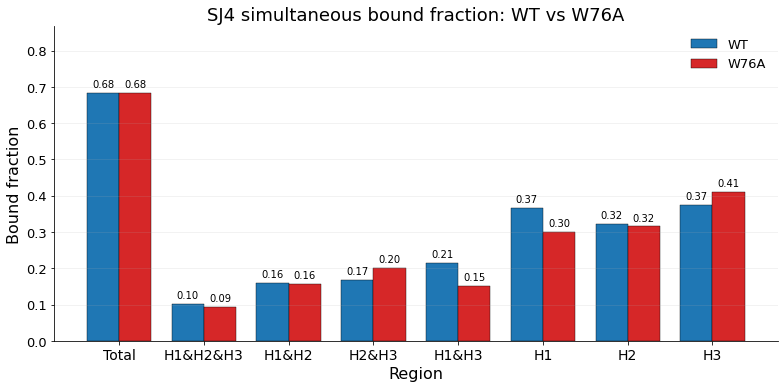

Saved plot  -> helix_region_bound_fractions_AND.png / .pdf


(<Figure size 792x396 with 1 Axes>,
 <AxesSubplot:title={'center':'SJ4 simultaneous bound fraction: WT vs W76A'}, xlabel='Region', ylabel='Bound fraction'>)

In [42]:
"""
Helix-region bound fractions: WT (traj1) vs W76A (traj2).

For each trajectory, compute the fraction of frames in which SJ4 is
simultaneously within 0.6 nm (heavy-atom-to-heavy-atom) of residues in the
specified set of helices (AND logic across helices):

    1. Total         - any protein residue
    2. H1 & H2 & H3  - \u22651 residue in H1 AND \u22651 in H2 AND \u22651 in H3
    3. H1 & H2       - \u22651 residue in H1 AND \u22651 in H2
    4. H2 & H3       - \u22651 residue in H2 AND \u22651 in H3
    5. H1 & H3       - \u22651 residue in H1 AND \u22651 in H3
    6. H1            - \u22651 residue in H1
    7. H2            - \u22651 residue in H2
    8. H3            - \u22651 residue in H3

Helix definitions (inclusive resSeq ranges):
    H1: PHE62 - ASN66   (resSeq 62-66)
    H2: GLU75 - GLU80   (resSeq 75-80)
    H3: GLU86 - TYR88   (resSeq 86-88)

Assumes `traj1` (WT) and `traj2` (W76A) are already loaded.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mdtraj as md

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
LIGAND_RESNAME = "SJ4"
CUTOFF_NM      = 0.6          # 6.0 Å

HELICES = {
    "H1": list(range(62, 66 + 1)),   # PHE62 .. ASN66
    "H2": list(range(75, 80 + 1)),   # GLU75 .. GLU80
    "H3": list(range(86, 88 + 1)),   # GLU86 .. TYR88
}

# -----------------------------------------------------------------------------
# 1. Per-frame contact arrays
# -----------------------------------------------------------------------------
def residue_ligand_contacts(traj, ligand_resname=LIGAND_RESNAME, cutoff_nm=CUTOFF_NM):
    """Return a (n_frames, n_prot_residues) boolean array: is each residue
    within `cutoff_nm` of any ligand heavy atom in each frame? Also returns
    the list of protein residues (same order as columns)."""
    top = traj.topology
    lig = [r for r in top.residues if r.name == ligand_resname]
    if not lig:
        raise ValueError(f"No residue named '{ligand_resname}' in topology.")
    lig_idx = lig[0].index

    prot_res = [r for r in top.residues if r.is_protein]
    pairs = np.array([[r.index, lig_idx] for r in prot_res])

    # min heavy-atom-heavy-atom distance per pair per frame, in nm
    d, _ = md.compute_contacts(traj, contacts=pairs,
                               scheme="closest-heavy", periodic=True)
    return d <= cutoff_nm, prot_res


def region_bound_fractions(traj, helices=HELICES):
    """Compute the 8 region bound fractions for one trajectory."""
    contact, prot_res = residue_ligand_contacts(traj)   # (n_frames, n_res), list
    resSeqs = np.array([r.resSeq for r in prot_res])

    # Per-helix per-frame: does SJ4 touch *any* residue in this helix?
    h_contact = {}
    for hname, hresSeqs in helices.items():
        mask = np.isin(resSeqs, list(hresSeqs))
        if not mask.any():
            print(f"[warn] no residues matched for {hname} "
                  f"(resSeqs {list(hresSeqs)} not found in protein).")
            h_contact[hname] = np.zeros(contact.shape[0], dtype=bool)
        else:
            h_contact[hname] = contact[:, mask].any(axis=1)

    total = contact.any(axis=1)     # any protein residue

    # AND logic: SJ4 must be simultaneously in contact with \u22651 residue in
    # each of the listed helices within the same frame.
    return {
        "Total":    total.mean(),
        "H1&H2&H3": (h_contact["H1"] & h_contact["H2"] & h_contact["H3"]).mean(),
        "H1&H2":    (h_contact["H1"] & h_contact["H2"]).mean(),
        "H2&H3":    (h_contact["H2"] & h_contact["H3"]).mean(),
        "H1&H3":    (h_contact["H1"] & h_contact["H3"]).mean(),
        "H1":       h_contact["H1"].mean(),
        "H2":       h_contact["H2"].mean(),
        "H3":       h_contact["H3"].mean(),
    }


# -----------------------------------------------------------------------------
# 2. Compute for both trajectories
# -----------------------------------------------------------------------------
res_wt  = region_bound_fractions(traj1)
res_mut = region_bound_fractions(traj2)

categories = list(res_wt.keys())
wt_vals  = np.array([res_wt[c]  for c in categories])
mut_vals = np.array([res_mut[c] for c in categories])

df = pd.DataFrame({
    "region":              categories,
    "bound_frac_WT":       wt_vals,
    "bound_frac_W76A":     mut_vals,
    "delta_W76A_minus_WT": mut_vals - wt_vals,
})
print(df.round(3).to_string(index=False))
df.to_csv("helix_region_bound_fractions_AND.csv", index=False)
print("\nSaved table -> helix_region_bound_fractions_AND.csv")

# -----------------------------------------------------------------------------
# 3. Grouped bar plot — same font-size knob pattern as before
# -----------------------------------------------------------------------------
def plot_region_bound_fractions(
    categories, wt_vals, mut_vals,
    *,
    # font sizes (pt)
    title_fs=18,
    axis_label_fs=16,
    xtick_fs=14,
    ytick_fs=13,
    legend_fs=13,
    value_label_fs=10,
    # styling
    figsize=(11, 5.5),
    bar_width=0.38,
    xtick_rotation=0,
    show_values=True,          # write the numeric value on top of each bar
    dpi=200,
    out_prefix="helix_region_bound_fractions_AND",
    title="SJ4 simultaneous bound fraction: WT vs W76A",
    wt_label="WT",
    mut_label="W76A",
    wt_color="#1f77b4",
    mut_color="#d62728",
    show=True,
):
    wt_vals  = np.asarray(wt_vals)
    mut_vals = np.asarray(mut_vals)
    n = len(categories)
    x = np.arange(n)
    w = bar_width

    fig, ax = plt.subplots(figsize=figsize)
    bars_wt  = ax.bar(x - w/2, wt_vals,  width=w, label=wt_label,
                      color=wt_color,  edgecolor="black", linewidth=0.4)
    bars_mut = ax.bar(x + w/2, mut_vals, width=w, label=mut_label,
                      color=mut_color, edgecolor="black", linewidth=0.4)

    ax.set_xlabel("Region",         fontsize=axis_label_fs)
    ax.set_ylabel("Bound fraction", fontsize=axis_label_fs)
    ax.set_title(title,             fontsize=title_fs)

    # Give headroom for value labels but cap at 1.05
    ymax_data = max(wt_vals.max(), mut_vals.max()) if n else 1.0
    ax.set_ylim(0, min(1.05, ymax_data * 1.15 + 0.08))

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=xtick_rotation, fontsize=xtick_fs)
    ax.tick_params(axis="y", labelsize=ytick_fs)
    ax.legend(frameon=False, fontsize=legend_fs)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    if show_values:
        for bars in (bars_wt, bars_mut):
            for b in bars:
                h = b.get_height()
                ax.text(b.get_x() + b.get_width()/2, h + 0.01,
                        f"{h:.2f}", ha="center", va="bottom",
                        fontsize=value_label_fs)

    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=dpi)
    fig.savefig(f"{out_prefix}.pdf")
    if show:
        plt.show()
    print(f"Saved plot  -> {out_prefix}.png / .pdf")
    return fig, ax


plot_region_bound_fractions(categories, wt_vals, mut_vals)

In [43]:
# """
# Compare experimental CSPs (WT p27 + SJ4, 800 MHz) with simulated WT bound
# fraction per residue.

# Plot:
#     - Bar chart : combined experimental CSP per residue (residues 58-105)
#     - axhline   : significance threshold = mean(CSP) + 2*std(CSP)
#     - Overlay   : bound fraction per residue (line, twin y-axis)
#                   with SEM-from-block-averaging shown as a fill_between band

# CSP combination follows Williamson (2013) Prog. NMR Spectrosc.:
#     CSP_ppm = sqrt(  dH_ppm**2 + (alpha * dN_ppm)**2 ),   alpha = 0.14
# The Excel sheet stores per-nucleus CSPs in Hz, so we divide by the
# spectrometer resonance frequency (1H: 800 MHz, 15N: 800 * gN/gH MHz).

# Assumes `traj1` (WT) is already loaded in memory.
# """

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import mdtraj as md

# # -----------------------------------------------------------------------------
# # Parameters
# # -----------------------------------------------------------------------------
# EXCEL_PATH            = "../WT_SJ4_800MHz.xlsx"   # path to the CSP workbook
# SPEC_MHZ_1H           = 800.0                  # 1H spectrometer freq, MHz
# GAMMA_N_OVER_GAMMA_H  = 0.10136767             # 15N/1H gyromagnetic ratio
# SPEC_MHZ_15N          = SPEC_MHZ_1H * GAMMA_N_OVER_GAMMA_H   # ~81.094 MHz
# ALPHA_N               = 0.2                   # 15N CSP scaling (Williamson)

# RES_MIN, RES_MAX      = 58, 105                # plot range
# THR_RES_MIN, THR_RES_MAX = 22, 105             # range used for threshold stats

# LIGAND_RESNAME        = "SJ4"
# CUTOFF_NM             = 0.6                    # 6 Å heavy-atom contact cutoff
# N_BLOCKS              = 5                      # blocks for SEM on bound fraction


# # -----------------------------------------------------------------------------
# # 1. Load + combine CSPs
# # -----------------------------------------------------------------------------
# def load_combined_csp(excel_path):
#     """Return DataFrame with combined CSP (ppm) per residue.

#     Uses the per-nucleus summary column at the end of each sheet
#     (`1H-CSP (Hz)` and `15N-CSP (Hz)`). Drops sidechain rows
#     (residue # like 's-W60') and merges 1H + 15N on residue number.
#     """
#     h = pd.read_excel(excel_path, sheet_name="1h-CSP (Hz)",  engine="openpyxl")
#     n = pd.read_excel(excel_path, sheet_name="15N-CSP (Hz)", engine="openpyxl")

#     h_col = h.columns[-1]   # '1H-CSP (Hz)'
#     n_col = n.columns[-1]   # '15N-CSP (Hz)'

#     # Drop non-numeric residue rows (sidechain peaks, blank separators)
#     h = h[pd.to_numeric(h["residue #"], errors="coerce").notna()].copy()
#     n = n[pd.to_numeric(n["residue #"], errors="coerce").notna()].copy()
#     h["residue #"] = h["residue #"].astype(int)
#     n["residue #"] = n["residue #"].astype(int)

#     merged = (
#         h[["residue #", "Residue", h_col]]
#         .merge(n[["residue #", n_col]], on="residue #", how="outer")
#         .sort_values("residue #")
#         .reset_index(drop=True)
#     )

#     # Hz -> ppm
#     dH_ppm = merged[h_col] / SPEC_MHZ_1H
#     dN_ppm = merged[n_col] / SPEC_MHZ_15N

#     # Combined CSP — fill missing with 0 so a residue with only one nucleus
#     # measured is not entirely lost; if BOTH are NaN (e.g. proline), keep NaN.
#     csp_ppm = np.sqrt(dH_ppm.fillna(0) ** 2 + (ALPHA_N * dN_ppm.fillna(0)) ** 2)
#     both_nan = merged[h_col].isna() & merged[n_col].isna()
#     csp_ppm[both_nan] = np.nan

#     out = pd.DataFrame({
#         "resSeq":  merged["residue #"].astype(int),
#         "Residue": merged["Residue"],
#         "dH_ppm":  dH_ppm,
#         "dN_ppm":  dN_ppm,
#         "CSP_ppm": csp_ppm,
#     })
#     # Defensive: collapse any accidental duplicate rows (e.g., dtype-mismatch
#     # in the outer merge) so a per-residue lookup is unique.
#     out = (out.sort_values(["resSeq", "CSP_ppm"], na_position="last")
#               .drop_duplicates("resSeq", keep="first")
#               .reset_index(drop=True))
#     return out


# csp_df = load_combined_csp(EXCEL_PATH)

# # -----------------------------------------------------------------------------
# # 2. Threshold = mean(CSP) + 2 * std(CSP)  -- computed over residues 22-105
# # -----------------------------------------------------------------------------
# csp_thr_pool = csp_df.loc[
#     (csp_df["resSeq"] >= THR_RES_MIN) & (csp_df["resSeq"] <= THR_RES_MAX),
#     "CSP_ppm",
# ].dropna()
# csp_mean  = csp_thr_pool.mean()
# csp_std   = csp_thr_pool.std(ddof=1)
# csp_threshold = csp_mean + 2 * csp_std
# print(f"CSP statistics over residues {THR_RES_MIN}-{THR_RES_MAX} "
#       f"(n={len(csp_thr_pool)}):")
# print(f"  mean = {csp_mean:.4f} ppm,  std = {csp_std:.4f} ppm")
# print(f"  threshold (mean + 2*std) = {csp_threshold:.4f} ppm")


# # -----------------------------------------------------------------------------
# # 3. Per-residue bound fraction with block-averaging SEM
# # -----------------------------------------------------------------------------
# def per_residue_bound_with_blocks(traj, n_blocks=N_BLOCKS,
#                                   ligand_resname=LIGAND_RESNAME,
#                                   cutoff_nm=CUTOFF_NM):
#     """Return DataFrame: resSeq, bound_frac (mean over all frames),
#     sem (across n_blocks contiguous blocks)."""
#     top = traj.topology
#     lig = [r for r in top.residues if r.name == ligand_resname]
#     if not lig:
#         raise ValueError(f"No '{ligand_resname}' residue in topology.")
#     lig_idx = lig[0].index

#     prot_res = [r for r in top.residues if r.is_protein]
#     pairs = np.array([[r.index, lig_idx] for r in prot_res])
#     d, _ = md.compute_contacts(traj, contacts=pairs,
#                                scheme="closest-heavy", periodic=True)
#     contact = (d <= cutoff_nm)                       # (n_frames, n_res)

#     n_frames = contact.shape[0]
#     block_size = n_frames // n_blocks
#     if block_size < 1:
#         raise ValueError(f"Trajectory too short for {n_blocks} blocks.")
#     block_means = np.zeros((n_blocks, contact.shape[1]))
#     for b in range(n_blocks):
#         s = b * block_size
#         e = (b + 1) * block_size if b < n_blocks - 1 else n_frames
#         block_means[b] = contact[s:e].mean(axis=0)

#     mean = contact.mean(axis=0)
#     sem  = block_means.std(axis=0, ddof=1) / np.sqrt(n_blocks)

#     return pd.DataFrame({
#         "resSeq":     [r.resSeq for r in prot_res],
#         "bound_frac": mean,
#         "sem":        sem,
#     })


# bf_df = per_residue_bound_with_blocks(traj1)

# # -----------------------------------------------------------------------------
# # 4. Restrict to plotting window 58-105 — use reindex() so both arrays end up
# #    with EXACTLY one row per residue position in the window (no duplicates,
# #    no missing rows).
# # -----------------------------------------------------------------------------
# res_range = np.arange(RES_MIN, RES_MAX + 1)

# csp_lookup = csp_df.drop_duplicates("resSeq").set_index("resSeq")
# bf_lookup  = bf_df .drop_duplicates("resSeq").set_index("resSeq")

# csp_p = csp_lookup.reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
# bf_p  = bf_lookup .reindex(res_range).reset_index().rename(columns={"index": "resSeq"})

# # Sanity check
# assert len(csp_p) == len(bf_p) == len(res_range), \
#     f"length mismatch: csp={len(csp_p)}, bf={len(bf_p)}, expected={len(res_range)}"

# merged_table = csp_p.merge(bf_p, on="resSeq", how="outer")
# merged_table.to_csv("csp_and_boundfrac_WT_58-105.csv", index=False)
# print("Saved table -> csp_and_boundfrac_WT_58-105.csv")


# # -----------------------------------------------------------------------------
# # 5. Plot — bars (CSP) + threshold line + twin-axis bound-fraction line/band
# # -----------------------------------------------------------------------------
# def plot_csp_with_boundfrac(
#     csp_p, bf_p, csp_threshold,
#     *,
#     # font sizes
#     title_fs=18,
#     axis_label_fs=16,
#     xtick_fs=11,
#     ytick_fs=13,
#     legend_fs=12,
#     # styling
#     figsize=None,
#     dpi=200,
#     out_prefix="csp_with_boundfrac_WT",
#     csp_color="#444444",
#     csp_above_color="#d62728",     # bars above threshold get this color
#     bf_color="#1f77b4",
#     threshold_color="#d62728",
#     title="Experimental CSP (WT p27\u2013SJ4, 800 MHz) with simulated bound fraction",
#     show=True,
# ):
#     res = csp_p["resSeq"].values
#     csp = csp_p["CSP_ppm"].values
#     bf  = bf_p["bound_frac"].values
#     sem = bf_p["sem"].values

#     n = len(res)
#     if figsize is None:
#         figsize = (max(10, n * 0.25), 5.8)

#     fig, ax = plt.subplots(figsize=figsize)

#     bar_colors = [
#         csp_above_color if (np.isfinite(c) and c >= csp_threshold) else csp_color
#         for c in csp
#     ]
#     bar_heights = np.where(np.isnan(csp), 0.0, csp)
#     ax.bar(res, bar_heights,
#            color=bar_colors, edgecolor="black", linewidth=0.3,
#            label="CSP (ppm)")

#     ax.axhline(csp_threshold, color=threshold_color, linestyle="--",
#                linewidth=1.3,
#                label=f"Threshold = mean + 2\u03c3 ({csp_threshold:.3f} ppm)")

#     ax.set_xlabel("Residue", fontsize=axis_label_fs)
#     ax.set_ylabel('Expt. $\Delta \delta$ (ppm)', fontsize=axis_label_fs)
#     ax.set_title(title, fontsize=title_fs)
#     ax.tick_params(axis="y", labelsize=ytick_fs)
#     ax.set_xlim(res.min() - 0.5, res.max() + 0.5)

#     # Tick every other residue if labels are crowded
#     step = 2 if n > 35 else 1
#     ax.set_xticks(res[::step])
#     ax.set_xticklabels(res[::step], rotation=90, fontsize=xtick_fs)
#     ax.spines["top"].set_visible(False)
#     ax.grid(axis="y", alpha=0.3, linewidth=0.5)

#     # Twin axis: bound fraction line + ±SEM band
#     ax2 = ax.twinx()
#     valid = np.isfinite(bf)
#     ax2.plot(res[valid], bf[valid],
#              color=bf_color, lw=2, marker="o", ms=3.5,
#              label="Bound fraction (WT)")
#     ax2.fill_between(res[valid],
#                      (bf - sem)[valid],
#                      (bf + sem)[valid],
#                      color=bf_color, alpha=0.25,
#                      label="\u00b1 SEM (block avg.)")
#     ax2.set_ylabel("Bound fraction", fontsize=axis_label_fs, color=bf_color)
#     ax2.tick_params(axis="y", labelsize=ytick_fs, colors=bf_color)
#     ax2.set_ylim(0, 0.4)
#     ax2.spines["top"].set_visible(False)

#     # Combined legend (bars+threshold from ax, line+band from ax2)
#     lines1, labels1 = ax.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
#     ax.legend(lines1 + lines2, labels1 + labels2,
#               loc="upper left", fontsize=legend_fs, frameon=False)

#     fig.tight_layout()
#     fig.savefig(f"{out_prefix}.png", dpi=dpi)
#     fig.savefig(f"{out_prefix}.pdf")
#     if show:
#         plt.show()
#     print(f"Saved plot -> {out_prefix}.png / .pdf")
#     return fig, ax, ax2


# plot_csp_with_boundfrac(csp_p, bf_p, csp_threshold)

CSP statistics over residues 22-105 (n=71):
  mean = 0.01 Hz,  std = 0.01 Hz
  threshold (mean + 2*std) = 0.03 Hz
Saved table -> csp_and_boundfrac_WT_58-105.csv


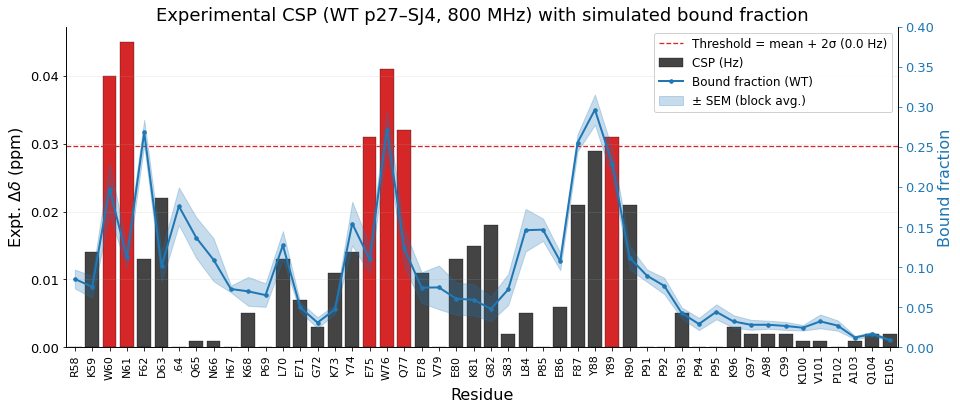

Saved plot -> csp_with_boundfrac_WT.png / .pdf


(<Figure size 967.68x417.6 with 2 Axes>,
 <AxesSubplot:title={'center':'Experimental CSP (WT p27–SJ4, 800 MHz) with simulated bound fraction'}, xlabel='Residue', ylabel='Expt. $\\Delta \\delta$ (ppm)'>,
 <AxesSubplot:ylabel='Bound fraction'>)

In [44]:
"""
Compare experimental CSPs (WT p27 + SJ4, 800 MHz) with simulated WT bound
fraction per residue.

Plot:
    - Bar chart : combined experimental CSP per residue (residues 58-105)
    - axhline   : significance threshold = mean(CSP) + 2*std(CSP)
    - Overlay   : bound fraction per residue (line, twin y-axis)
                  with SEM-from-block-averaging shown as a fill_between band

CSP combination follows Williamson (2013) Prog. NMR Spectrosc.:
    CSP_ppm = sqrt(  dH_ppm**2 + (alpha * dN_ppm)**2 ),   alpha = 0.14
The Excel sheet stores per-nucleus CSPs in Hz, so we divide by the
spectrometer resonance frequency (1H: 800 MHz, 15N: 800 * gN/gH MHz).

Assumes `traj1` (WT) is already loaded in memory.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mdtraj as md

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
EXCEL_PATH            = "../WT_SJ4_800MHz.xlsx"   # path to the CSP workbook
SPEC_MHZ_1H           = 800.0                  # 1H spectrometer freq, MHz
GAMMA_N_OVER_GAMMA_H  = 0.10136767             # 15N/1H gyromagnetic ratio
SPEC_MHZ_15N          = SPEC_MHZ_1H * GAMMA_N_OVER_GAMMA_H   # ~81.094 MHz
ALPHA_N               = 0.20                  # 15N CSP scaling (Williamson)

RES_MIN, RES_MAX      = 58, 105                # plot range
THR_RES_MIN, THR_RES_MAX = 22, 105             # range used for threshold stats

LIGAND_RESNAME        = "SJ4"
CUTOFF_NM             = 0.6                    # 6 Å heavy-atom contact cutoff
N_BLOCKS              = 5                      # blocks for SEM on bound fraction


# -----------------------------------------------------------------------------
# 1. Load + combine CSPs
# -----------------------------------------------------------------------------
def load_combined_csp(excel_path):
    """Return DataFrame with combined CSP (ppm) per residue.

    Uses the per-nucleus summary column at the end of each sheet
    (`1H-CSP (Hz)` and `15N-CSP (Hz)`). Drops sidechain rows
    (residue # like 's-W60') and merges 1H + 15N on residue number.
    """
    h = pd.read_excel(excel_path, sheet_name="1h-CSP (Hz)",  engine="openpyxl")
    n = pd.read_excel(excel_path, sheet_name="15N-CSP (Hz)", engine="openpyxl")

    h_col = h.columns[-1]   # '1H-CSP (Hz)'
    n_col = n.columns[-1]   # '15N-CSP (Hz)'

    # Drop non-numeric residue rows (sidechain peaks, blank separators)
    h = h[pd.to_numeric(h["residue #"], errors="coerce").notna()].copy()
    n = n[pd.to_numeric(n["residue #"], errors="coerce").notna()].copy()
    h["residue #"] = h["residue #"].astype(int)
    n["residue #"] = n["residue #"].astype(int)

    merged = (
        h[["residue #", "Residue", h_col]]
        .merge(n[["residue #", n_col]], on="residue #", how="outer")
        .sort_values("residue #")
        .reset_index(drop=True)
    )

    # Hz -> ppm
    dH_ppm = merged[h_col] / SPEC_MHZ_1H
    dN_ppm = merged[n_col] / SPEC_MHZ_15N

    # Combined CSP — fill missing with 0 so a residue with only one nucleus
    # measured is not entirely lost; if BOTH are NaN (e.g. proline), keep NaN.
    csp_ppm = np.sqrt(dH_ppm.fillna(0) ** 2 + (ALPHA_N * dN_ppm.fillna(0)) ** 2)
    both_nan = merged[h_col].isna() & merged[n_col].isna()
    csp_ppm[both_nan] = np.nan

    # Combined CSP in Hz = combined ppm scaled to the 1H spectrometer frequency
    # (the standard "proton-equivalent Hz" used in many CSP figures).
    csp_hz = csp_ppm * SPEC_MHZ_1H

    out = pd.DataFrame({
        "resSeq":  merged["residue #"].astype(int),
        "Residue": merged["Residue"],
        "dH_ppm":  dH_ppm,
        "dN_ppm":  dN_ppm,
        "CSP_ppm": csp_ppm,
        "CSP_Hz":  csp_hz,
    })
    # Defensive: collapse any accidental duplicate rows (e.g., dtype-mismatch
    # in the outer merge) so a per-residue lookup is unique.
    out = (out.sort_values(["resSeq", "CSP_ppm"], na_position="last")
              .drop_duplicates("resSeq", keep="first")
              .reset_index(drop=True))
    return out


csp_df = load_combined_csp(EXCEL_PATH)

# -----------------------------------------------------------------------------
# 2. Threshold = mean(CSP) + 2 * std(CSP)  -- computed over residues 22-105
# -----------------------------------------------------------------------------
csp_thr_pool = csp_df.loc[
    (csp_df["resSeq"] >= THR_RES_MIN) & (csp_df["resSeq"] <= THR_RES_MAX),
    "CSP_ppm",
].dropna()
csp_mean  = csp_thr_pool.mean()
csp_std   = csp_thr_pool.std(ddof=1)
csp_threshold = csp_mean + 2 * csp_std
print(f"CSP statistics over residues {THR_RES_MIN}-{THR_RES_MAX} "
      f"(n={len(csp_thr_pool)}):")
print(f"  mean = {csp_mean:.2f} Hz,  std = {csp_std:.2f} Hz")
print(f"  threshold (mean + 2*std) = {csp_threshold:.2f} Hz")


# -----------------------------------------------------------------------------
# 3. Per-residue bound fraction with block-averaging SEM
# -----------------------------------------------------------------------------
def per_residue_bound_with_blocks(traj, n_blocks=N_BLOCKS,
                                  ligand_resname=LIGAND_RESNAME,
                                  cutoff_nm=CUTOFF_NM):
    """Return DataFrame: resSeq, bound_frac (mean over all frames),
    sem (across n_blocks contiguous blocks)."""
    top = traj.topology
    lig = [r for r in top.residues if r.name == ligand_resname]
    if not lig:
        raise ValueError(f"No '{ligand_resname}' residue in topology.")
    lig_idx = lig[0].index

    prot_res = [r for r in top.residues if r.is_protein]
    pairs = np.array([[r.index, lig_idx] for r in prot_res])
    d, _ = md.compute_contacts(traj, contacts=pairs,
                               scheme="closest-heavy", periodic=True)
    contact = (d <= cutoff_nm)                       # (n_frames, n_res)

    n_frames = contact.shape[0]
    block_size = n_frames // n_blocks
    if block_size < 1:
        raise ValueError(f"Trajectory too short for {n_blocks} blocks.")
    block_means = np.zeros((n_blocks, contact.shape[1]))
    for b in range(n_blocks):
        s = b * block_size
        e = (b + 1) * block_size if b < n_blocks - 1 else n_frames
        block_means[b] = contact[s:e].mean(axis=0)

    mean = contact.mean(axis=0)
    sem  = block_means.std(axis=0, ddof=1) / np.sqrt(n_blocks)

    return pd.DataFrame({
        "resSeq":     [r.resSeq for r in prot_res],
        "bound_frac": mean,
        "sem":        sem,
    })


bf_df = per_residue_bound_with_blocks(traj1)

# -----------------------------------------------------------------------------
# 4. Restrict to plotting window 58-105 — use reindex() so both arrays end up
#    with EXACTLY one row per residue position in the window (no duplicates,
#    no missing rows).
# -----------------------------------------------------------------------------
res_range = np.arange(RES_MIN, RES_MAX + 1)

csp_lookup = csp_df.drop_duplicates("resSeq").set_index("resSeq")
bf_lookup  = bf_df .drop_duplicates("resSeq").set_index("resSeq")

csp_p = csp_lookup.reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
bf_p  = bf_lookup .reindex(res_range).reset_index().rename(columns={"index": "resSeq"})

# Sanity check
assert len(csp_p) == len(bf_p) == len(res_range), \
    f"length mismatch: csp={len(csp_p)}, bf={len(bf_p)}, expected={len(res_range)}"

merged_table = csp_p.merge(bf_p, on="resSeq", how="outer")
merged_table.to_csv("csp_and_boundfrac_WT_58-105.csv", index=False)
print("Saved table -> csp_and_boundfrac_WT_58-105.csv")


# -----------------------------------------------------------------------------
# 5. Plot — bars (CSP) + threshold line + twin-axis bound-fraction line/band
# -----------------------------------------------------------------------------
# One-letter fallback map, used if the Excel row for a residue is missing
# (e.g., prolines) so we can still label the tick with a sensible letter.
_THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "HID": "H", "HIE": "H", "HIP": "H", "HSD": "H", "HSE": "H", "HSP": "H",
}


def _tick_labels(csp_p):
    """One label per row of csp_p of the form '<one-letter><resSeq>'.

    Prefers the 'Residue' column from the Excel (already formatted like
    'E22'/'W76'). For rows where that is NaN (e.g., prolines absent from
    the CSP sheet), fall back to '.<resSeq>' as an unknown marker.
    """
    labels = []
    for _, row in csp_p.iterrows():
        res_num = int(row["resSeq"])
        name = row.get("Residue")
        if isinstance(name, str) and name.strip():
            name = name.strip()
            # Already 1-letter+number (e.g. 'E22')?  Use as-is.
            if name[0].isalpha() and name[1:].lstrip("-").isdigit():
                labels.append(name)
                continue
            # Three-letter + number (e.g. 'PHE62') -> convert.
            three = name[:3].upper()
            if three in _THREE_TO_ONE:
                labels.append(f"{_THREE_TO_ONE[three]}{res_num}")
                continue
        labels.append(f".{res_num}")     # unknown name
    return labels


def plot_csp_with_boundfrac(
    csp_p, bf_p, csp_threshold,
    *,
    # font sizes
    title_fs=18,
    axis_label_fs=16,
    xtick_fs=11,
    ytick_fs=13,
    legend_fs=12,
    # styling
    figsize=None,
    dpi=200,
    out_prefix="csp_with_boundfrac_WT",
    csp_color="#444444",
    csp_above_color="#d62728",     # bars above threshold get this color
    bf_color="#1f77b4",
    threshold_color="#d62728",
    title="Experimental CSP (WT p27\u2013SJ4, 800 MHz) with simulated bound fraction",
    # legend placement
    legend_loc="upper right",
    legend_bbox=None,              # e.g. (1.18, 1.0) to push outside the axes
    xtick_step=1,                  # 1 = every residue, 2 = every other, ...
    show=True,
):
    res = csp_p["resSeq"].values
    csp = csp_p["CSP_ppm"].values
    bf  = bf_p["bound_frac"].values
    sem = bf_p["sem"].values
    labels = _tick_labels(csp_p)

    n = len(res)
    if figsize is None:
        figsize = (max(10, n * 0.28), 5.8)

    fig, ax = plt.subplots(figsize=figsize)

    bar_colors = [
        csp_above_color if (np.isfinite(c) and c >= csp_threshold) else csp_color
        for c in csp
    ]
    bar_heights = np.where(np.isnan(csp), 0.0, csp)
    ax.bar(res, bar_heights,
           color=bar_colors, edgecolor="black", linewidth=0.3,
           label="CSP (Hz)")

    ax.axhline(csp_threshold, color=threshold_color, linestyle="--",
               linewidth=1.3,
               label=f"Threshold = mean + 2\u03c3 ({csp_threshold:.1f} Hz)")

    ax.set_xlabel("Residue", fontsize=axis_label_fs)
    ax.set_ylabel('Expt. $\Delta \delta$ (ppm)', fontsize=axis_label_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="y", labelsize=ytick_fs)
    ax.set_xlim(res.min() - 0.5, res.max() + 0.5)

    # Custom tick labels: <one-letter><resSeq>, optionally thinned via xtick_step
    tick_idx = np.arange(0, n, xtick_step)
    ax.set_xticks(res[tick_idx])
    ax.set_xticklabels([labels[i] for i in tick_idx],
                       rotation=90, fontsize=xtick_fs)
    ax.spines["top"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    # Twin axis: bound fraction line + ±SEM band
    ax2 = ax.twinx()
    valid = np.isfinite(bf)
    ax2.plot(res[valid], bf[valid],
             color=bf_color, lw=2, marker="o", ms=3.5,
             label="Bound fraction (WT)")
    ax2.fill_between(res[valid],
                     (bf - sem)[valid],
                     (bf + sem)[valid],
                     color=bf_color, alpha=0.25,
                     label="\u00b1 SEM (block avg.)")
    ax2.set_ylabel("Bound fraction", fontsize=axis_label_fs, color=bf_color)
    ax2.tick_params(axis="y", labelsize=ytick_fs, colors=bf_color)
    ax2.set_ylim(0, 0.4)
    ax2.spines["top"].set_visible(False)

    # Combined legend on the right side. Drawn on ax2 so it sits on top.
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg_kwargs = dict(fontsize=legend_fs, frameon=True, framealpha=0.9)
    if legend_bbox is not None:
        leg_kwargs.update(dict(loc=legend_loc, bbox_to_anchor=legend_bbox,
                               borderaxespad=0.))
    else:
        leg_kwargs["loc"] = legend_loc
    ax2.legend(lines1 + lines2, labels1 + labels2, **leg_kwargs)

    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=dpi)
    fig.savefig(f"{out_prefix}.pdf")
    if show:
        plt.show()
    print(f"Saved plot -> {out_prefix}.png / .pdf")
    return fig, ax, ax2


# Default: legend pinned at upper-right, inside the axes. If bars on the right
# end up overlapping it, push the legend OUTSIDE by passing
# `legend_bbox=(1.18, 1.0)` (and maybe shrink the figure width slightly).
plot_csp_with_boundfrac(csp_p, bf_p, csp_threshold)

W76A CSP statistics over residues 22-105 (n=84):
  mean = 0.00 Hz,  std = 0.00 Hz
  threshold (mean + 2*std) = 0.00 Hz


/Users/kaushikborthakur1211/opt/anaconda3/envs/New_env/lib/python3.7/site-packages/openpyxl/worksheet/_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Saved table -> csp_and_boundfrac_W76A_58-105.csv


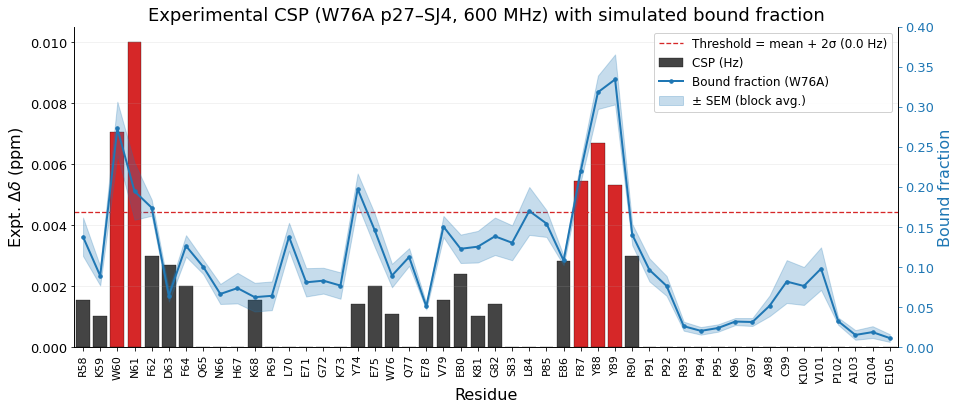

Saved plot -> csp_with_boundfrac_W76A.png / .pdf


(<Figure size 967.68x417.6 with 2 Axes>,
 <AxesSubplot:title={'center':'Experimental CSP (W76A p27–SJ4, 600 MHz) with simulated bound fraction'}, xlabel='Residue', ylabel='Expt. $\\Delta \\delta$ (ppm)'>,
 <AxesSubplot:ylabel='Bound fraction'>)

In [45]:
"""
Same analysis as the WT version, but for the W76A p27 + SJ4 dataset
(600 MHz spectrometer, single 1000 uM titration endpoint).

Plot:
    - Bar chart : combined experimental CSP (Hz) per residue, 58-105
    - axhline   : threshold = mean(CSP) + 2*std(CSP) over residues 22-105
    - Overlay   : per-residue bound fraction from traj2 (W76A) on a twin
                  y-axis, with SEM-from-block-averaging shown as a band

Excel layout (differs from the WT workbook):
    Sheet `CSP-plot` provides per-nucleus CSPs in Hz at the 1000 uM point:
        - CSP1000[1H] (Hz)
        - CSP1000[15N] (Hz)
    Other rows in the sheet (header band, Ave/StDev rows, sidechain peak)
    are filtered out by keeping only rows whose 'Residue' cell looks like
    a single letter followed by digits (e.g. 'E22', 'W76').

Assumes `traj2` (W76A) is already loaded in memory.
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mdtraj as md

# -----------------------------------------------------------------------------
# Parameters
# -----------------------------------------------------------------------------
EXCEL_PATH            = "../W76A_SJ4_600MHz.xlsx"
SHEET_NAME            = "CSP-plot"
SPEC_MHZ_1H           = 600.0                  # 1H spectrometer freq, MHz
GAMMA_N_OVER_GAMMA_H  = 0.10136767
SPEC_MHZ_15N          = SPEC_MHZ_1H * GAMMA_N_OVER_GAMMA_H   # ~60.82 MHz
ALPHA_N               = 0.2                   # Williamson (2013) default

RES_MIN, RES_MAX      = 58, 105                # plot range
THR_RES_MIN, THR_RES_MAX = 22, 105             # range for threshold stats

LIGAND_RESNAME        = "SJ4"
CUTOFF_NM             = 0.6                    # 6 Å heavy-atom cutoff
N_BLOCKS              = 5

RESIDUE_REGEX = re.compile(r"^([A-Z])(\d+)$")  # e.g. 'E22', 'W76'


# -----------------------------------------------------------------------------
# 1. Load and combine CSPs from the W76A workbook
# -----------------------------------------------------------------------------
def load_combined_csp_w76a(excel_path=EXCEL_PATH, sheet=SHEET_NAME,
                           spec_1h=SPEC_MHZ_1H, alpha_n=ALPHA_N):
    """Return DataFrame: resSeq, Residue, dH_ppm, dN_ppm, CSP_ppm, CSP_Hz."""
    df = pd.read_excel(excel_path, sheet_name=sheet, engine="openpyxl")

    # Find the needed columns robustly (names might have trailing spaces etc.)
    def pick(predicate, label):
        for c in df.columns:
            if predicate(str(c)):
                return c
        raise KeyError(f"No column matching '{label}' in sheet '{sheet}'. "
                       f"Columns: {list(df.columns)}")

    h_col   = pick(lambda c: "1H"  in c and "Hz" in c, "1H ... Hz")
    n_col   = pick(lambda c: "15N" in c and "Hz" in c, "15N ... Hz")
    res_col = pick(lambda c: c.strip().lower() == "residue", "Residue")

    # Keep only rows whose Residue cell looks like '<letter><digits>'
    res_str = df[res_col].astype(str).str.strip()
    mask = res_str.str.match(RESIDUE_REGEX.pattern)
    sub = df.loc[mask].copy()
    sub["resSeq"]   = res_str[mask].str.extract(RESIDUE_REGEX.pattern)[1].astype(int).values
    sub["Residue"]  = res_str[mask].values

    # Per-nucleus CSPs in Hz -> ppm via resonance frequencies
    dH_hz = pd.to_numeric(sub[h_col], errors="coerce")
    dN_hz = pd.to_numeric(sub[n_col], errors="coerce")

    dH_ppm = dH_hz / spec_1h
    dN_ppm = dN_hz / (spec_1h * GAMMA_N_OVER_GAMMA_H)

    # Williamson combined CSP (ppm)
    csp_ppm = np.sqrt(dH_ppm.fillna(0) ** 2 + (alpha_n * dN_ppm.fillna(0)) ** 2)
    both_nan = dH_ppm.isna() & dN_ppm.isna()
    csp_ppm[both_nan] = np.nan

    # Scale to proton-equivalent Hz for plotting
    csp_hz = csp_ppm * spec_1h

    out = pd.DataFrame({
        "resSeq":  sub["resSeq"].values,
        "Residue": sub["Residue"].values,
        "dH_ppm":  dH_ppm.values,
        "dN_ppm":  dN_ppm.values,
        "CSP_ppm": csp_ppm.values,
        "CSP_Hz":  csp_hz.values,
    })
    out = (out.sort_values(["resSeq", "CSP_Hz"], na_position="last")
              .drop_duplicates("resSeq", keep="first")
              .reset_index(drop=True))
    return out


csp_df = load_combined_csp_w76a()

# -----------------------------------------------------------------------------
# 2. Threshold = mean(CSP_Hz) + 2 * std(CSP_Hz) over residues 22-105
# -----------------------------------------------------------------------------
csp_thr_pool = csp_df.loc[
    (csp_df["resSeq"] >= THR_RES_MIN) & (csp_df["resSeq"] <= THR_RES_MAX),
    "CSP_ppm",
].dropna()
csp_mean = csp_thr_pool.mean()
csp_std  = csp_thr_pool.std(ddof=1)
csp_threshold = csp_mean + 2 * csp_std
print(f"W76A CSP statistics over residues {THR_RES_MIN}-{THR_RES_MAX} "
      f"(n={len(csp_thr_pool)}):")
print(f"  mean = {csp_mean:.2f} Hz,  std = {csp_std:.2f} Hz")
print(f"  threshold (mean + 2*std) = {csp_threshold:.2f} Hz")


# -----------------------------------------------------------------------------
# 3. Per-residue bound fraction for W76A (traj2), block-averaging SEM
# -----------------------------------------------------------------------------
def per_residue_bound_with_blocks(traj, n_blocks=N_BLOCKS,
                                  ligand_resname=LIGAND_RESNAME,
                                  cutoff_nm=CUTOFF_NM):
    top = traj.topology
    lig = [r for r in top.residues if r.name == ligand_resname]
    if not lig:
        raise ValueError(f"No '{ligand_resname}' residue in topology.")
    lig_idx = lig[0].index

    prot_res = [r for r in top.residues if r.is_protein]
    pairs = np.array([[r.index, lig_idx] for r in prot_res])
    d, _ = md.compute_contacts(traj, contacts=pairs,
                               scheme="closest-heavy", periodic=True)
    contact = (d <= cutoff_nm)

    n_frames = contact.shape[0]
    block_size = n_frames // n_blocks
    if block_size < 1:
        raise ValueError(f"Trajectory too short for {n_blocks} blocks.")
    block_means = np.zeros((n_blocks, contact.shape[1]))
    for b in range(n_blocks):
        s = b * block_size
        e = (b + 1) * block_size if b < n_blocks - 1 else n_frames
        block_means[b] = contact[s:e].mean(axis=0)

    mean = contact.mean(axis=0)
    sem  = block_means.std(axis=0, ddof=1) / np.sqrt(n_blocks)
    return pd.DataFrame({
        "resSeq":     [r.resSeq for r in prot_res],
        "bound_frac": mean,
        "sem":        sem,
    })


bf_df = per_residue_bound_with_blocks(traj2)

# -----------------------------------------------------------------------------
# 4. Align to plotting window
# -----------------------------------------------------------------------------
res_range = np.arange(RES_MIN, RES_MAX + 1)
csp_lookup = csp_df.drop_duplicates("resSeq").set_index("resSeq")
bf_lookup  = bf_df .drop_duplicates("resSeq").set_index("resSeq")
csp_p = csp_lookup.reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
bf_p  = bf_lookup .reindex(res_range).reset_index().rename(columns={"index": "resSeq"})

assert len(csp_p) == len(bf_p) == len(res_range), \
    f"length mismatch: csp={len(csp_p)}, bf={len(bf_p)}, expected={len(res_range)}"

csp_p.merge(bf_p, on="resSeq", how="outer").to_csv(
    "csp_and_boundfrac_W76A_58-105.csv", index=False)
print("Saved table -> csp_and_boundfrac_W76A_58-105.csv")


# -----------------------------------------------------------------------------
# 5. Plot  (same visual style as the WT version)
# -----------------------------------------------------------------------------
_THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "HID": "H", "HIE": "H", "HIP": "H", "HSD": "H", "HSE": "H", "HSP": "H",
}


def _tick_labels(csp_p):
    labels = []
    for _, row in csp_p.iterrows():
        res_num = int(row["resSeq"])
        name = row.get("Residue")
        if isinstance(name, str) and name.strip():
            name = name.strip()
            if name[0].isalpha() and name[1:].lstrip("-").isdigit():
                labels.append(name)
                continue
            three = name[:3].upper()
            if three in _THREE_TO_ONE:
                labels.append(f"{_THREE_TO_ONE[three]}{res_num}")
                continue
        labels.append(f".{res_num}")
    return labels


def plot_csp_with_boundfrac(
    csp_p, bf_p, csp_threshold,
    *,
    title_fs=18,
    axis_label_fs=16,
    xtick_fs=11,
    ytick_fs=13,
    legend_fs=12,
    figsize=None,
    dpi=200,
    out_prefix="csp_with_boundfrac_W76A",
    csp_color="#444444",
    csp_above_color="#d62728",
    bf_color="#1f77b4",
    threshold_color="#d62728",
    title="Experimental CSP (W76A p27\u2013SJ4, 600 MHz) with simulated bound fraction",
    legend_loc="upper right",
    legend_bbox=None,            # e.g. (1.18, 1.0) to push OUTSIDE the axes
    xtick_step=1,
    show=True,
):
    res = csp_p["resSeq"].values
    csp = csp_p["CSP_ppm"].values
    bf  = bf_p["bound_frac"].values
    sem = bf_p["sem"].values
    labels = _tick_labels(csp_p)

    n = len(res)
    if figsize is None:
        figsize = (max(10, n * 0.28), 5.8)

    fig, ax = plt.subplots(figsize=figsize)

    bar_colors = [
        csp_above_color if (np.isfinite(c) and c >= csp_threshold) else csp_color
        for c in csp
    ]
    bar_heights = np.where(np.isnan(csp), 0.0, csp)
    ax.bar(res, bar_heights, color=bar_colors,
           edgecolor="black", linewidth=0.3, label="CSP (Hz)")

    ax.axhline(csp_threshold, color=threshold_color, linestyle="--",
               linewidth=1.3,
               label=f"Threshold = mean + 2\u03c3 ({csp_threshold:.1f} Hz)")

    ax.set_xlabel("Residue", fontsize=axis_label_fs)
    ax.set_ylabel('Expt. $\Delta \delta$ (ppm)', fontsize=axis_label_fs)
    ax.set_title(title, fontsize=title_fs)
    ax.tick_params(axis="y", labelsize=ytick_fs)
    ax.set_xlim(res.min() - 0.5, res.max() + 0.5)

    tick_idx = np.arange(0, n, xtick_step)
    ax.set_xticks(res[tick_idx])
    ax.set_xticklabels([labels[i] for i in tick_idx],
                       rotation=90, fontsize=xtick_fs)
    ax.spines["top"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    ax2 = ax.twinx()
    valid = np.isfinite(bf)
    ax2.plot(res[valid], bf[valid],
             color=bf_color, lw=2, marker="o", ms=3.5,
             label="Bound fraction (W76A)")
    ax2.fill_between(res[valid],
                     (bf - sem)[valid],
                     (bf + sem)[valid],
                     color=bf_color, alpha=0.25,
                     label="\u00b1 SEM (block avg.)")
    ax2.set_ylabel("Bound fraction", fontsize=axis_label_fs, color=bf_color)
    ax2.tick_params(axis="y", labelsize=ytick_fs, colors=bf_color)
    ax2.set_ylim(0, 0.4)
    ax2.spines["top"].set_visible(False)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    leg_kwargs = dict(fontsize=legend_fs, frameon=True, framealpha=0.9)
    if legend_bbox is not None:
        leg_kwargs.update(dict(loc=legend_loc, bbox_to_anchor=legend_bbox,
                               borderaxespad=0.))
    else:
        leg_kwargs["loc"] = legend_loc
    ax2.legend(lines1 + lines2, labels1 + labels2, **leg_kwargs)

    fig.tight_layout()
    fig.savefig(f"{out_prefix}.png", dpi=dpi)
    fig.savefig(f"{out_prefix}.pdf")
    if show:
        plt.show()
    print(f"Saved plot -> {out_prefix}.png / .pdf")
    return fig, ax, ax2


plot_csp_with_boundfrac(csp_p, bf_p, csp_threshold)

In [46]:
# """
# Same analysis as the WT version, but for the W76A p27 + SJ4 dataset
# (600 MHz spectrometer, single 1000 uM titration endpoint).

# Plot:
#     - Bar chart : combined experimental CSP (Hz) per residue, 58-105
#     - axhline   : threshold = mean(CSP) + 2*std(CSP) over residues 22-105
#     - Overlay   : per-residue bound fraction from traj2 (W76A) on a twin
#                   y-axis, with SEM-from-block-averaging shown as a band

# Excel layout (differs from the WT workbook):
#     Sheet `CSP-plot` provides per-nucleus CSPs in Hz at the 1000 uM point:
#         - CSP1000[1H] (Hz)
#         - CSP1000[15N] (Hz)
#     Other rows in the sheet (header band, Ave/StDev rows, sidechain peak)
#     are filtered out by keeping only rows whose 'Residue' cell looks like
#     a single letter followed by digits (e.g. 'E22', 'W76').

# Assumes `traj2` (W76A) is already loaded in memory.
# """

# import re
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import mdtraj as md

# # -----------------------------------------------------------------------------
# # Parameters
# # -----------------------------------------------------------------------------
# EXCEL_PATH            = "../W76A_SJ4_600MHz.xlsx"
# SHEET_NAME            = "CSP-plot"
# SPEC_MHZ_1H           = 600.0                  # 1H spectrometer freq, MHz
# GAMMA_N_OVER_GAMMA_H  = 0.10136767
# SPEC_MHZ_15N          = SPEC_MHZ_1H * GAMMA_N_OVER_GAMMA_H   # ~60.82 MHz
# ALPHA_N               = 0.2                   # Williamson (2013) default

# RES_MIN, RES_MAX      = 58, 105                # plot range
# THR_RES_MIN, THR_RES_MAX = 22, 105             # range for threshold stats

# LIGAND_RESNAME        = "SJ4"
# CUTOFF_NM             = 0.6                    # 6 Å heavy-atom cutoff
# N_BLOCKS              = 5

# RESIDUE_REGEX = re.compile(r"^([A-Z])(\d+)$")  # e.g. 'E22', 'W76'


# # -----------------------------------------------------------------------------
# # 1. Load and combine CSPs from the W76A workbook
# # -----------------------------------------------------------------------------
# def load_combined_csp_w76a(excel_path=EXCEL_PATH, sheet=SHEET_NAME,
#                            spec_1h=SPEC_MHZ_1H, alpha_n=ALPHA_N):
#     """Return DataFrame: resSeq, Residue, dH_ppm, dN_ppm, CSP_ppm, CSP_Hz."""
#     df = pd.read_excel(excel_path, sheet_name=sheet, engine="openpyxl")

#     # Find the needed columns robustly (names might have trailing spaces etc.)
#     def pick(predicate, label):
#         for c in df.columns:
#             if predicate(str(c)):
#                 return c
#         raise KeyError(f"No column matching '{label}' in sheet '{sheet}'. "
#                        f"Columns: {list(df.columns)}")

#     h_col   = pick(lambda c: "1H"  in c and "Hz" in c, "1H ... Hz")
#     n_col   = pick(lambda c: "15N" in c and "Hz" in c, "15N ... Hz")
#     res_col = pick(lambda c: c.strip().lower() == "residue", "Residue")

#     # Keep only rows whose Residue cell looks like '<letter><digits>'
#     res_str = df[res_col].astype(str).str.strip()
#     mask = res_str.str.match(RESIDUE_REGEX.pattern)
#     sub = df.loc[mask].copy()
#     sub["resSeq"]   = res_str[mask].str.extract(RESIDUE_REGEX.pattern)[1].astype(int).values
#     sub["Residue"]  = res_str[mask].values

#     # Per-nucleus CSPs in Hz -> ppm via resonance frequencies
#     dH_hz = pd.to_numeric(sub[h_col], errors="coerce")
#     dN_hz = pd.to_numeric(sub[n_col], errors="coerce")

#     dH_ppm = dH_hz / spec_1h
#     dN_ppm = dN_hz / (spec_1h * GAMMA_N_OVER_GAMMA_H)

#     # Williamson combined CSP (ppm)
#     csp_ppm = np.sqrt(dH_ppm.fillna(0) ** 2 + (alpha_n * dN_ppm.fillna(0)) ** 2)
#     both_nan = dH_ppm.isna() & dN_ppm.isna()
#     csp_ppm[both_nan] = np.nan

#     # Scale to proton-equivalent Hz for plotting
#     csp_hz = csp_ppm * spec_1h

#     out = pd.DataFrame({
#         "resSeq":  sub["resSeq"].values,
#         "Residue": sub["Residue"].values,
#         "dH_ppm":  dH_ppm.values,
#         "dN_ppm":  dN_ppm.values,
#         "CSP_ppm": csp_ppm.values,
#         "CSP_Hz":  csp_hz.values,
#     })
#     out = (out.sort_values(["resSeq", "CSP_Hz"], na_position="last")
#               .drop_duplicates("resSeq", keep="first")
#               .reset_index(drop=True))
#     return out


# csp_df = load_combined_csp_w76a()

# # -----------------------------------------------------------------------------
# # 2. Threshold = mean(CSP_Hz) + 2 * std(CSP_Hz) over residues 22-105
# # -----------------------------------------------------------------------------
# csp_thr_pool = csp_df.loc[
#     (csp_df["resSeq"] >= THR_RES_MIN) & (csp_df["resSeq"] <= THR_RES_MAX),
#     "CSP_ppm",
# ].dropna()
# csp_mean = csp_thr_pool.mean()
# csp_std  = csp_thr_pool.std(ddof=1)
# csp_threshold = csp_mean + 2 * csp_std
# print(f"W76A CSP statistics over residues {THR_RES_MIN}-{THR_RES_MAX} "
#       f"(n={len(csp_thr_pool)}):")
# print(f"  mean = {csp_mean:.2f} Hz,  std = {csp_std:.2f} Hz")
# print(f"  threshold (mean + 2*std) = {csp_threshold:.2f} Hz")


# # -----------------------------------------------------------------------------
# # 3. Per-residue bound fraction for W76A (traj2), block-averaging SEM
# # -----------------------------------------------------------------------------
# def per_residue_bound_with_blocks(traj, n_blocks=N_BLOCKS,
#                                   ligand_resname=LIGAND_RESNAME,
#                                   cutoff_nm=CUTOFF_NM):
#     top = traj.topology
#     lig = [r for r in top.residues if r.name == ligand_resname]
#     if not lig:
#         raise ValueError(f"No '{ligand_resname}' residue in topology.")
#     lig_idx = lig[0].index

#     prot_res = [r for r in top.residues if r.is_protein]
#     pairs = np.array([[r.index, lig_idx] for r in prot_res])
#     d, _ = md.compute_contacts(traj, contacts=pairs,
#                                scheme="closest-heavy", periodic=True)
#     contact = (d <= cutoff_nm)

#     n_frames = contact.shape[0]
#     block_size = n_frames // n_blocks
#     if block_size < 1:
#         raise ValueError(f"Trajectory too short for {n_blocks} blocks.")
#     block_means = np.zeros((n_blocks, contact.shape[1]))
#     for b in range(n_blocks):
#         s = b * block_size
#         e = (b + 1) * block_size if b < n_blocks - 1 else n_frames
#         block_means[b] = contact[s:e].mean(axis=0)

#     mean = contact.mean(axis=0)
#     sem  = block_means.std(axis=0, ddof=1) / np.sqrt(n_blocks)
#     return pd.DataFrame({
#         "resSeq":     [r.resSeq for r in prot_res],
#         "bound_frac": mean,
#         "sem":        sem,
#     })


# bf_df = per_residue_bound_with_blocks(traj2)

# # -----------------------------------------------------------------------------
# # 4. Align to plotting window
# # -----------------------------------------------------------------------------
# res_range = np.arange(RES_MIN, RES_MAX + 1)
# csp_lookup = csp_df.drop_duplicates("resSeq").set_index("resSeq")
# bf_lookup  = bf_df .drop_duplicates("resSeq").set_index("resSeq")
# csp_p = csp_lookup.reindex(res_range).reset_index().rename(columns={"index": "resSeq"})
# bf_p  = bf_lookup .reindex(res_range).reset_index().rename(columns={"index": "resSeq"})

# assert len(csp_p) == len(bf_p) == len(res_range), \
#     f"length mismatch: csp={len(csp_p)}, bf={len(bf_p)}, expected={len(res_range)}"

# csp_p.merge(bf_p, on="resSeq", how="outer").to_csv(
#     "csp_and_boundfrac_W76A_58-105.csv", index=False)
# print("Saved table -> csp_and_boundfrac_W76A_58-105.csv")


# # -----------------------------------------------------------------------------
# # 5. Plot  (same visual style as the WT version)
# # -----------------------------------------------------------------------------
# _THREE_TO_ONE = {
#     "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
#     "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
#     "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
#     "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
#     "HID": "H", "HIE": "H", "HIP": "H", "HSD": "H", "HSE": "H", "HSP": "H",
# }


# def _tick_labels(csp_p):
#     labels = []
#     for _, row in csp_p.iterrows():
#         res_num = int(row["resSeq"])
#         name = row.get("Residue")
#         if isinstance(name, str) and name.strip():
#             name = name.strip()
#             if name[0].isalpha() and name[1:].lstrip("-").isdigit():
#                 labels.append(name)
#                 continue
#             three = name[:3].upper()
#             if three in _THREE_TO_ONE:
#                 labels.append(f"{_THREE_TO_ONE[three]}{res_num}")
#                 continue
#         labels.append(f".{res_num}")
#     return labels


# def plot_csp_with_boundfrac(
#     csp_p, bf_p, csp_threshold,
#     *,
#     title_fs=18,
#     axis_label_fs=16,
#     xtick_fs=11,
#     ytick_fs=13,
#     legend_fs=12,
#     figsize=None,
#     dpi=200,
#     out_prefix="csp_with_boundfrac_W76A",
#     csp_color="#444444",
#     csp_above_color="#d62728",
#     bf_color="#1f77b4",
#     threshold_color="#d62728",
#     title="Experimental CSP (W76A p27\u2013SJ4, 600 MHz) with simulated bound fraction",
#     legend_loc="upper right",
#     legend_bbox=None,            # e.g. (1.18, 1.0) to push OUTSIDE the axes
#     xtick_step=1,
#     show=True,
# ):
#     res = csp_p["resSeq"].values
#     csp = csp_p["CSP_ppm"].values
#     bf  = bf_p["bound_frac"].values
#     sem = bf_p["sem"].values
#     labels = _tick_labels(csp_p)

#     n = len(res)
#     if figsize is None:
#         figsize = (max(10, n * 0.28), 5.8)

#     fig, ax = plt.subplots(figsize=figsize)

#     bar_colors = [
#         csp_above_color if (np.isfinite(c) and c >= csp_threshold) else csp_color
#         for c in csp
#     ]
#     bar_heights = np.where(np.isnan(csp), 0.0, csp)
#     ax.bar(res, bar_heights, color=bar_colors,
#            edgecolor="black", linewidth=0.3, label="CSP (Hz)")

#     ax.axhline(csp_threshold, color=threshold_color, linestyle="--",
#                linewidth=1.3,
#                label=f"Threshold = mean + 2\u03c3 ({csp_threshold:.1f} Hz)")

#     ax.set_xlabel("Residue", fontsize=axis_label_fs)
#     ax.set_ylabel('Expt. $\Delta \delta$ (ppm)', fontsize=axis_label_fs)
#     ax.set_title(title, fontsize=title_fs)
#     ax.tick_params(axis="y", labelsize=ytick_fs)
#     ax.set_xlim(res.min() - 0.5, res.max() + 0.5)

#     tick_idx = np.arange(0, n, xtick_step)
#     ax.set_xticks(res[tick_idx])
#     ax.set_xticklabels([labels[i] for i in tick_idx],
#                        rotation=90, fontsize=xtick_fs)
#     ax.spines["top"].set_visible(False)
#     ax.grid(axis="y", alpha=0.3, linewidth=0.5)
#     ax.set_ylim(0,0.04)

#     ax2 = ax.twinx()
#     valid = np.isfinite(bf)
#     ax2.plot(res[valid], bf[valid],
#              color=bf_color, lw=2, marker="o", ms=3.5,
#              label="Bound fraction (W76A)")
#     ax2.fill_between(res[valid],
#                      (bf - sem)[valid],
#                      (bf + sem)[valid],
#                      color=bf_color, alpha=0.25,
#                      label="\u00b1 SEM (block avg.)")
#     ax2.set_ylabel("Bound fraction", fontsize=axis_label_fs, color=bf_color)
#     ax2.tick_params(axis="y", labelsize=ytick_fs, colors=bf_color)
#     ax2.set_ylim(0, 0.4)
#     ax2.spines["top"].set_visible(False)

#     lines1, labels1 = ax.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
#     leg_kwargs = dict(fontsize=legend_fs, frameon=True, framealpha=0.9)
#     if legend_bbox is not None:
#         leg_kwargs.update(dict(loc=legend_loc, bbox_to_anchor=legend_bbox,
#                                borderaxespad=0.))
#     else:
#         leg_kwargs["loc"] = legend_loc
#     ax2.legend(lines1 + lines2, labels1 + labels2, **leg_kwargs)

#     fig.tight_layout()
#     fig.savefig(f"{out_prefix}.png", dpi=dpi)
#     fig.savefig(f"{out_prefix}.pdf")
#     if show:
#         plt.show()
#     print(f"Saved plot -> {out_prefix}.png / .pdf")
#     return fig, ax, ax2


# plot_csp_with_boundfrac(csp_p, bf_p, csp_threshold)

Loading WT CSP (800 MHz) ...
Loading W76A CSP (600 MHz) ...

WT CSP threshold (res 22-105):
  mean=0.0078 ppm  std=0.0109 ppm  threshold=0.0296 ppm

--- Pearson correlation WITHOUT 3-residue window ---
  n residues = 38
  r = 0.7494,  p = 6.19e-08

--- Pearson correlation WITH 3-residue window ---
  n residues = 42
  r = 0.7613,  p = 4.80e-09

Saved -> csp_correlation_WT_vs_W76A_58-105.csv


/Users/kaushikborthakur1211/opt/anaconda3/envs/New_env/lib/python3.7/site-packages/openpyxl/worksheet/_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Saved -> csp_bars_WT_and_W76A.png / .pdf


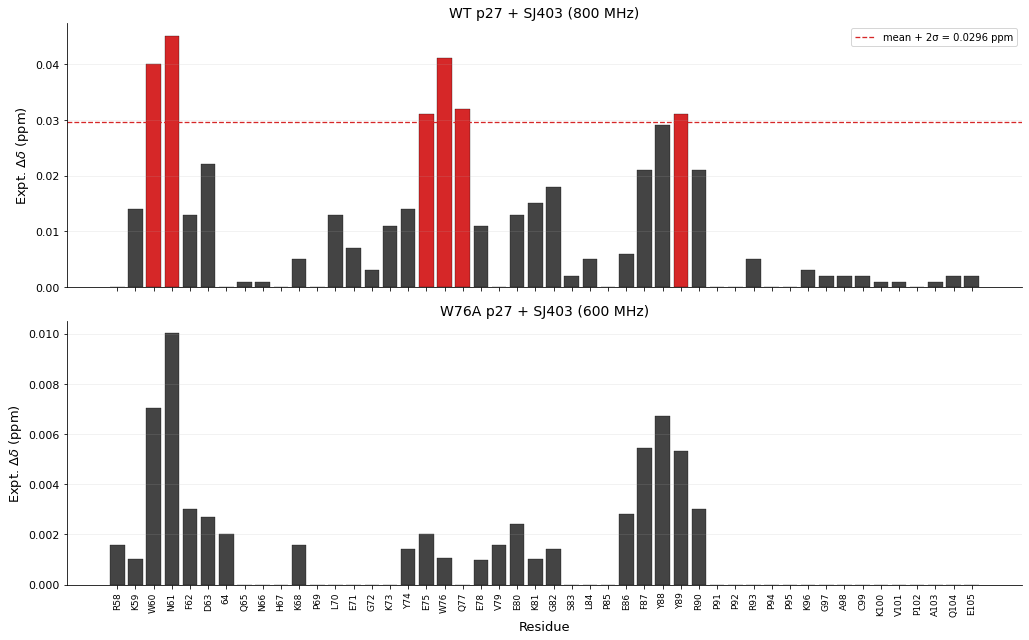

Saved -> csp_correlation_scatter_WT_vs_W76A.png / .pdf


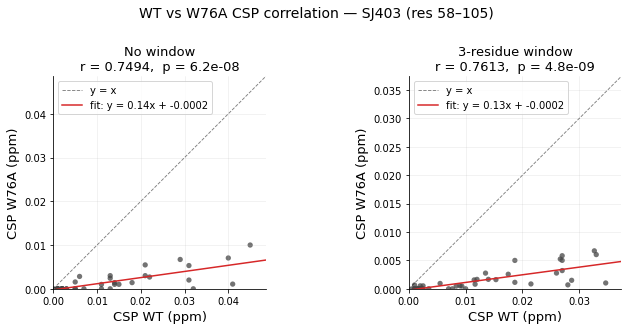

In [47]:
"""
csp_correlation_WT_vs_W76A.py
-------------------------------
Loads CSP data for WT (800 MHz) and W76A (600 MHz) with ligand SJ403,
computes combined CSP in ppm for both, then reports Pearson correlation
with and without a 3-residue rolling window.

WT file  : WT_SJ4_800MHz.xlsx   — sheets "1h-CSP (Hz)" and "15N-CSP (Hz)"
           last column = final-titration CSP in Hz
W76A file: W76A_SJ4_600MHz.xlsx — sheet "CSP"
           col 7  = CSP[1H] (Hz)  at highest [ligand]  (1000 uM)
           col 8  = CSP[15N] (Hz) at highest [ligand]  (1000 uM)
           (col indices 0-based, after reading with header=None)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# =============================================================================
# USER SETTINGS — edit paths and parameters here
# =============================================================================
WT_EXCEL    = "WT_SJ4_800MHz.xlsx"
W76A_EXCEL  = "W76A_SJ4_600MHz.xlsx"

SPEC_MHZ_1H_WT   = 800.0
SPEC_MHZ_1H_W76A = 600.0

GAMMA_N_OVER_GAMMA_H = 0.10136767
ALPHA_N              = 0.20          # weighting factor for 15N in combined CSP

RES_MIN, RES_MAX         = 58, 105   # residue range for plotting / correlation
THR_RES_MIN, THR_RES_MAX = 22, 105   # residue range for threshold calculation

# =============================================================================
# Amino-acid 3→1 letter lookup (for x-tick labels)
# =============================================================================
_THREE_TO_ONE = {
    "ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C",
    "GLN":"Q","GLU":"E","GLY":"G","HIS":"H","ILE":"I",
    "LEU":"L","LYS":"K","MET":"M","PHE":"F","PRO":"P",
    "SER":"S","THR":"T","TRP":"W","TYR":"Y","VAL":"V",
    "HID":"H","HIE":"H","HIP":"H","HSD":"H","HSE":"H","HSP":"H",
}

def _tick_labels(resSeq_arr, residue_name_arr):
    labels = []
    for res_num, name in zip(resSeq_arr, residue_name_arr):
        res_num = int(res_num)
        if isinstance(name, str) and name.strip():
            name = name.strip()
            # already formatted like "K59"
            if name[0].isalpha() and name[1:].lstrip("-").isdigit():
                labels.append(name)
                continue
            three = name[:3].upper()
            if three in _THREE_TO_ONE:
                labels.append(f"{_THREE_TO_ONE[three]}{res_num}")
                continue
        labels.append(str(res_num))
    return labels

# =============================================================================
# 1.  Load WT  (800 MHz)
# =============================================================================
def load_wt_csp(excel_path=WT_EXCEL, spec_mhz=SPEC_MHZ_1H_WT):
    """
    Reads 'last column' of each sheet as the final-titration CSP in Hz,
    converts to ppm, computes combined CSP.
    """
    h = pd.read_excel(excel_path, sheet_name="1h-CSP (Hz)",  engine="openpyxl")
    n = pd.read_excel(excel_path, sheet_name="15N-CSP (Hz)", engine="openpyxl")

    h_col = h.columns[-1]   # "1H-CSP (Hz)"
    n_col = n.columns[-1]   # "15N-CSP (Hz)"

    # keep only numeric residue rows
    h = h[pd.to_numeric(h["residue #"], errors="coerce").notna()].copy()
    n = n[pd.to_numeric(n["residue #"], errors="coerce").notna()].copy()
    h["residue #"] = h["residue #"].astype(int)
    n["residue #"] = n["residue #"].astype(int)

    merged = (
        h[["residue #", "Residue", h_col]]
        .merge(n[["residue #", n_col]], on="residue #", how="outer")
        .sort_values("residue #")
        .reset_index(drop=True)
    )

    spec_15n = spec_mhz * GAMMA_N_OVER_GAMMA_H
    dH_ppm   = merged[h_col] / spec_mhz
    dN_ppm   = merged[n_col] / spec_15n
    csp_ppm  = np.sqrt(dH_ppm.fillna(0)**2 + (ALPHA_N * dN_ppm.fillna(0))**2)
    both_nan = merged[h_col].isna() & merged[n_col].isna()
    csp_ppm[both_nan] = np.nan

    out = pd.DataFrame({
        "resSeq":  merged["residue #"].astype(int),
        "Residue": merged["Residue"],
        "CSP_ppm": csp_ppm,
    })
    out = (out.sort_values(["resSeq", "CSP_ppm"], na_position="last")
              .drop_duplicates("resSeq", keep="first")
              .reset_index(drop=True))
    return out


# =============================================================================
# 2.  Load W76A  (600 MHz)
# =============================================================================
def load_w76a_csp(excel_path=W76A_EXCEL, spec_mhz=SPEC_MHZ_1H_W76A):
    """
    Reads the CSP-plot sheet by column name, matching the logic
    in the standalone W76A script.
    """
    df = pd.read_excel(excel_path, sheet_name="CSP-plot", engine="openpyxl")

    # Find Hz columns robustly by name
    def pick(predicate):
        for c in df.columns:
            if predicate(str(c)):
                return c
        raise KeyError(f"No matching column. Available: {list(df.columns)}")

    h_col   = pick(lambda c: "1H"  in c and "Hz" in c)
    n_col   = pick(lambda c: "15N" in c and "Hz" in c)
    res_col = pick(lambda c: c.strip().lower() == "residue")

    # Keep only rows like 'E22', 'W76' — filters out header/Ave/StDev rows
    res_str = df[res_col].astype(str).str.strip()
    mask    = res_str.str.match(r"^[A-Z]\d+$")
    sub     = df.loc[mask].copy()

    res_seq = res_str[mask].str.extract(r"^[A-Z](\d+)$")[0].astype(int).values

    spec_15n = spec_mhz * GAMMA_N_OVER_GAMMA_H
    h_hz = pd.to_numeric(sub[h_col], errors="coerce")
    n_hz = pd.to_numeric(sub[n_col], errors="coerce")

    dH_ppm  = h_hz / spec_mhz
    dN_ppm  = n_hz / spec_15n
    csp_ppm = np.sqrt(dH_ppm.fillna(0)**2 + (ALPHA_N * dN_ppm.fillna(0))**2)
    csp_ppm[h_hz.isna() & n_hz.isna()] = np.nan

    out = pd.DataFrame({
        "resSeq":  res_seq,
        "Residue": res_str[mask].values,
        "CSP_ppm": csp_ppm.values,
    })
    return (out.sort_values(["resSeq", "CSP_ppm"], na_position="last")
               .drop_duplicates("resSeq", keep="first")
               .reset_index(drop=True))

# =============================================================================
# 3.  Load both datasets
# =============================================================================
print("Loading WT CSP (800 MHz) ...")
wt_df   = load_wt_csp()

print("Loading W76A CSP (600 MHz) ...")
w76a_df = load_w76a_csp()

# =============================================================================
# 4.  Threshold for WT  (mean + 2*std over residues 22-105, ppm)
# =============================================================================
wt_thr_pool = wt_df.loc[
    (wt_df["resSeq"] >= THR_RES_MIN) & (wt_df["resSeq"] <= THR_RES_MAX),
    "CSP_ppm",
].dropna()
wt_mean      = wt_thr_pool.mean()
wt_std       = wt_thr_pool.std(ddof=1)
wt_threshold = wt_mean + 2 * wt_std
print(f"\nWT CSP threshold (res {THR_RES_MIN}-{THR_RES_MAX}):")
print(f"  mean={wt_mean:.4f} ppm  std={wt_std:.4f} ppm  "
      f"threshold={wt_threshold:.4f} ppm")

# =============================================================================
# 5.  Align both to residues 58-105
# =============================================================================
res_range = np.arange(RES_MIN, RES_MAX + 1)

wt_idx   = wt_df  .drop_duplicates("resSeq").set_index("resSeq")
w76a_idx = w76a_df.drop_duplicates("resSeq").set_index("resSeq")

wt_aligned   = wt_idx  .reindex(res_range)
w76a_aligned = w76a_idx.reindex(res_range)

corr_df = pd.DataFrame({
    "resSeq":   res_range,
    "Residue":  wt_aligned["Residue"].values,   # use WT residue names for labels
    "CSP_WT":   wt_aligned  ["CSP_ppm"].values,
    "CSP_W76A": w76a_aligned["CSP_ppm"].values,
})

# =============================================================================
# 6.  Correlation WITHOUT 3-residue window
# =============================================================================
mask_raw = (
    pd.to_numeric(corr_df["CSP_WT"],   errors="coerce").notna() &
    pd.to_numeric(corr_df["CSP_W76A"], errors="coerce").notna()
)
r_raw, p_raw = pearsonr(
    corr_df.loc[mask_raw, "CSP_WT"].astype(float),
    corr_df.loc[mask_raw, "CSP_W76A"].astype(float),
)
print(f"\n--- Pearson correlation WITHOUT 3-residue window ---")
print(f"  n residues = {mask_raw.sum()}")
print(f"  r = {r_raw:.4f},  p = {p_raw:.2e}")

# =============================================================================
# 7.  Correlation WITH 3-residue rolling window
# =============================================================================
corr_df["CSP_WT_smooth"]   = (
    corr_df["CSP_WT"].astype(float)
    .rolling(window=3, center=True, min_periods=2).mean()
)
corr_df["CSP_W76A_smooth"] = (
    corr_df["CSP_W76A"].astype(float)
    .rolling(window=3, center=True, min_periods=2).mean()
)

mask_smooth = corr_df["CSP_WT_smooth"].notna() & corr_df["CSP_W76A_smooth"].notna()
r_smooth, p_smooth = pearsonr(
    corr_df.loc[mask_smooth, "CSP_WT_smooth"],
    corr_df.loc[mask_smooth, "CSP_W76A_smooth"],
)
print(f"\n--- Pearson correlation WITH 3-residue window ---")
print(f"  n residues = {mask_smooth.sum()}")
print(f"  r = {r_smooth:.4f},  p = {p_smooth:.2e}")

# save table
corr_df.to_csv("csp_correlation_WT_vs_W76A_58-105.csv", index=False)
print("\nSaved -> csp_correlation_WT_vs_W76A_58-105.csv")

# =============================================================================
# 8.  Figure 1 — side-by-side CSP bar plots (WT and W76A, ppm)
# =============================================================================
labels = _tick_labels(corr_df["resSeq"].values, corr_df["Residue"].values)
n      = len(res_range)

fig, axes = plt.subplots(2, 1, figsize=(max(12, n * 0.30), 9), sharex=True)

for ax, col, threshold, title, color_above in [
    (axes[0], "CSP_WT",   wt_threshold,
     f"WT p27 + SJ403 (800 MHz)",   "#d62728"),
    (axes[1], "CSP_W76A", None,
     f"W76A p27 + SJ403 (600 MHz)", "#d62728"),
]:
    vals = corr_df[col].astype(float).values
    bar_h = np.where(np.isnan(vals), 0.0, vals)

    if threshold is not None:
        bar_colors = [
            color_above if (np.isfinite(v) and v >= threshold) else "#444444"
            for v in vals
        ]
    else:
        bar_colors = "#444444"

    ax.bar(res_range, bar_h, color=bar_colors,
           edgecolor="black", linewidth=0.3)

    if threshold is not None:
        ax.axhline(threshold, color=color_above, linestyle="--", linewidth=1.3,
                   label=f"mean + 2σ = {threshold:.4f} ppm")
        ax.legend(fontsize=10)

    ax.set_ylabel(r"Expt. $\Delta\delta$ (ppm)", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.tick_params(axis="y", labelsize=11)

axes[1].set_xticks(res_range)
axes[1].set_xticklabels(labels, rotation=90, fontsize=9)
axes[1].set_xlabel("Residue", fontsize=13)

fig.tight_layout()
fig.savefig("csp_bars_WT_and_W76A.png", dpi=200, bbox_inches="tight")
fig.savefig("csp_bars_WT_and_W76A.pdf", bbox_inches="tight")
print("Saved -> csp_bars_WT_and_W76A.png / .pdf")
plt.show()

# =============================================================================
# 9.  Figure 2 — correlation scatter plots (with and without window)
# =============================================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, (x_col, y_col, mask, r_val, p_val, panel_title) in zip(axes2, [
    ("CSP_WT",        "CSP_W76A",
     mask_raw,    r_raw,    p_raw,    "No window"),
    ("CSP_WT_smooth", "CSP_W76A_smooth",
     mask_smooth, r_smooth, p_smooth, "3-residue window"),
]):
    x = corr_df.loc[mask, x_col].astype(float).values
    y = corr_df.loc[mask, y_col].astype(float).values

    ax.scatter(x, y, color="#444444", s=28, alpha=0.75, edgecolors="none")

    lim = max(np.nanmax(x), np.nanmax(y)) * 1.08
    ax.plot([0, lim], [0, lim], "k--", lw=0.9, alpha=0.5, label="y = x")

    m, b = np.polyfit(x, y, 1)
    xs   = np.linspace(0, lim, 200)
    ax.plot(xs, m * xs + b, color="#d62728", lw=1.5,
            label=f"fit: y = {m:.2f}x + {b:.4f}")

    ax.set_xlabel("CSP WT (ppm)",   fontsize=13)
    ax.set_ylabel("CSP W76A (ppm)", fontsize=13)
    ax.set_title(f"{panel_title}\nr = {r_val:.4f},  p = {p_val:.1e}",
                 fontsize=13)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal")
    ax.legend(fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.3, linewidth=0.5)

fig2.suptitle("WT vs W76A CSP correlation — SJ403 (res 58–105)",
              fontsize=14, y=1.01)
fig2.tight_layout()
fig2.savefig("csp_correlation_scatter_WT_vs_W76A.png", dpi=200,
             bbox_inches="tight")
fig2.savefig("csp_correlation_scatter_WT_vs_W76A.pdf", bbox_inches="tight")
print("Saved -> csp_correlation_scatter_WT_vs_W76A.png / .pdf")
plt.show()